# Baltic macroeconomic normalized dashboard snapshot: rolling

This notebook renders dynamic z-score visuals for the Baltic countries using explicit view-level configs.

It is organized as two complementary views built from the same pipeline outputs:

- `presentation`: a shareable rolling-normalization story with GDP-family growth transforms, compact provenance, and curated export-friendly charts
- `methodology`: a reviewer-facing QA view with normalization context, selected-source provenance, anomaly tables, and the underlying dynamic charts

- Countries covered: Lithuania, Latvia, Estonia
- Visuals: `zscore_heatmap` and `zscore_timelines`
- Source batch root: `bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics`
- Dynamic output root: `bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics_rolling_10y`
- Available notebook views: `presentation`, `methodology`

## View config contract

The parameter cell defines two explicit top-level configs:

- `presentation_view_config` for the audience-facing rolling-plus-growth story
- `methodology_view_config` for mixed-mode and provenance review
- `active_notebook_view_name` to choose which config the shared helper defaults render

The notebook now includes dedicated presentation and methodology sections below, while the shared helpers still support the active view selector for additional variants.

Use the presentation section when you want the cleanest narrative for peers. Use the methodology section when you want to trace a chart back to its selected source, normalization rule, or flagged anomaly rows.

## Optional nominal GDP growth variant

If you want the presentation view to include nominal GDP growth as well, clone the presentation config and replace its transformation strategy.

```python
presentation_nominal_gdp_view = dict(presentation_view_config)
presentation_nominal_gdp_view["transformation_strategy"] = (
    build_recommended_gdp_growth_transformation_strategy(include_nominal_gdp=True)
)
_lt_presentation_nominal_context = _render_country_presentation_section(
    "LT",
    view_config=presentation_nominal_gdp_view,
)
```


In [8]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

current_dir = Path.cwd()
search_roots = [current_dir, *current_dir.parents]
module_path = next(
    (
        p
        for p in search_roots
        if (p / "macro_indicator_core.py").exists() and (p / "macro_indicator_pipeline.py").exists()
    ),
    None,
)
if module_path is None:
    module_path = next((p for p in search_roots if (p / "macro_indicator_pipeline.py").exists()), None)
if module_path is None:
    raise FileNotFoundError("macro_indicator_pipeline.py not found in current or parent directories.")

if str(module_path.resolve()) not in sys.path:
    sys.path.insert(0, str(module_path.resolve()))

from macro_indicator_pipeline import (
    build_recommended_gdp_growth_transformation_strategy,
    build_country_zscore_notebook_context,
    build_static_zscore_charts,
    display_country_zscore_visuals,
    get_pipeline_root,
    run_country_batch,
)


In [9]:
root = get_pipeline_root()
project_subdir = Path("bs2026_student_projects") / "Arturas_Sotnicenko"
source_output_root = root / project_subdir / "outputs_baltics"
rolling_output_root = root / project_subdir / "outputs_baltics_rolling_10y"

country_codes = ("LT", "LV", "EE")
chart_profile = "harmonized_overlay"

presentation_normalization_config = {
    "mode": "rolling_trailing",
    "rolling_window_years": 10,
    "exclude_current_from_window": True,
    "min_obs_for_zscore": 5,
}
presentation_view_config = {
    "view_name": "presentation",
    "view_title": "Presentation view",
    "description": "Uniform rolling normalization with GDP-family growth transforms for audience-facing sharing.",
    "normalization_config": presentation_normalization_config,
    "transformation_strategy": build_recommended_gdp_growth_transformation_strategy(),
    "region_label": "Baltics presentation",
    "force_refresh": False,
}

methodology_normalization_config = {
    "mode": "rolling_trailing",
    "rolling_window_years": 10,
    "exclude_current_from_window": True,
    "min_obs_for_zscore": 5,
    "indicator_overrides": {
        "gdp_current_usd": {
            "mode": "static_baseline",
            "baseline_start_year": 1999,
            "min_obs_for_zscore": 3,
            "limit_to_baseline_window": True,
        },
        "gdp_per_capita": {
            "mode": "static_baseline",
            "baseline_start_year": 1999,
            "min_obs_for_zscore": 3,
            "limit_to_baseline_window": True,
        },
        "real_gdp": {
            "mode": "static_baseline",
            "baseline_start_year": 1999,
            "min_obs_for_zscore": 3,
            "limit_to_baseline_window": True,
        },
    },
}
methodology_view_config = {
    "view_name": "methodology",
    "view_title": "Methodology view",
    "description": "Mixed-mode normalization and provenance review matching the current QA-oriented notebook baseline.",
    "normalization_config": methodology_normalization_config,
    "transformation_strategy": None,
    "region_label": "Baltics methodology",
    "force_refresh": False,
}

notebook_view_configs = {
    "presentation": presentation_view_config,
    "methodology": methodology_view_config,
}
active_notebook_view_name = "methodology"
active_notebook_view_config = notebook_view_configs[active_notebook_view_name]

# Legacy globals kept for compatibility with the existing helper defaults.
normalization_config = active_notebook_view_config["normalization_config"]
transformation_strategy = active_notebook_view_config["transformation_strategy"]
normalized_region_label = active_notebook_view_config["region_label"]
force_zscore_refresh = active_notebook_view_config["force_refresh"]

print(f"Countries: {country_codes}")
print(f"Chart profile: {chart_profile}")
print(f"Source output root: {source_output_root.resolve()}")
print(f"Rolling output root: {rolling_output_root.resolve()}")
print(f"Available notebook views: {tuple(notebook_view_configs)}")
print(f"Active notebook view: {active_notebook_view_name}")
print(f"Active view title: {active_notebook_view_config['view_title']}")
print(f"Active view description: {active_notebook_view_config['description']}")
print(f"Active normalization config: {normalization_config}")
print(f"Active transformation enabled: {transformation_strategy is not None}")
print(f"Active transformation strategy: {transformation_strategy}")


Countries: ('LT', 'LV', 'EE')
Chart profile: harmonized_overlay
Source output root: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics
Rolling output root: /workspaces/da-ai/bs2026_student_projects/Arturas_Sotnicenko/outputs_baltics_rolling_10y
Available notebook views: ('presentation', 'methodology')
Active notebook view: methodology
Active view title: Methodology view
Active view description: Mixed-mode normalization and provenance review matching the current QA-oriented notebook baseline.
Active normalization config: {'mode': 'rolling_trailing', 'rolling_window_years': 10, 'exclude_current_from_window': True, 'min_obs_for_zscore': 5, 'indicator_overrides': {'gdp_current_usd': {'mode': 'static_baseline', 'baseline_start_year': 1999, 'min_obs_for_zscore': 3, 'limit_to_baseline_window': True}, 'gdp_per_capita': {'mode': 'static_baseline', 'baseline_start_year': 1999, 'min_obs_for_zscore': 3, 'limit_to_baseline_window': True}, 'real_gdp': {'mode': 'static_basel

In [10]:
batch = run_country_batch(
    country_codes=country_codes,
    outdir_root=str(source_output_root),
    include_analysis=True,
    reuse_existing=True,
    chart_profile=chart_profile,
)

country_results = batch["country_results"]
rolling_country_output_dirs = {
    country_code: rolling_output_root / country_code
    for country_code in country_codes
}
for output_dir in rolling_country_output_dirs.values():
    output_dir.mkdir(parents=True, exist_ok=True)


In [11]:
_USE_CURRENT_NOTEBOOK_DEFAULT = object()

def _resolve_notebook_view_config(view_config):
    if view_config is _USE_CURRENT_NOTEBOOK_DEFAULT:
        view_config = globals().get("active_notebook_view_config")
    return view_config if isinstance(view_config, dict) else {}

def _build_country_rolling_context(
    country_code: str,
    *,
    view_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    normalization_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    transformation_strategy=_USE_CURRENT_NOTEBOOK_DEFAULT,
    region_label=_USE_CURRENT_NOTEBOOK_DEFAULT,
    force_refresh=_USE_CURRENT_NOTEBOOK_DEFAULT,
):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    if normalization_config is _USE_CURRENT_NOTEBOOK_DEFAULT:
        normalization_config = resolved_view_config.get("normalization_config", globals().get("normalization_config"))
    if transformation_strategy is _USE_CURRENT_NOTEBOOK_DEFAULT:
        transformation_strategy = resolved_view_config.get(
            "transformation_strategy",
            globals().get("transformation_strategy"),
        )
    if region_label is _USE_CURRENT_NOTEBOOK_DEFAULT:
        region_label = resolved_view_config.get("region_label", globals().get("normalized_region_label"))
    if force_refresh is _USE_CURRENT_NOTEBOOK_DEFAULT:
        force_refresh = resolved_view_config.get("force_refresh", globals().get("force_zscore_refresh", False))
    return build_country_zscore_notebook_context(
        country_code=country_code,
        country_results=country_results[country_code],
        country_output_dir=rolling_country_output_dirs[country_code],
        normalization_config=normalization_config,
        transformation_strategy=transformation_strategy,
        region_label=region_label,
        force_refresh=force_refresh,
        root=root,
    )

def _render_country_rolling_section(
    country_code: str,
    *,
    view_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    normalization_config=_USE_CURRENT_NOTEBOOK_DEFAULT,
    transformation_strategy=_USE_CURRENT_NOTEBOOK_DEFAULT,
    region_label=_USE_CURRENT_NOTEBOOK_DEFAULT,
    force_refresh=_USE_CURRENT_NOTEBOOK_DEFAULT,
    display_visuals: bool = True,
):
    country_context = _build_country_rolling_context(
        country_code,
        view_config=view_config,
        normalization_config=normalization_config,
        transformation_strategy=transformation_strategy,
        region_label=region_label,
        force_refresh=force_refresh,
    )
    if display_visuals:
        display_country_zscore_visuals(country_context)
    return country_context

def _build_indicator_label_lookup(country_context, *, metadata_key="zscore_chart_label_metadata"):
    metadata = country_context.get(metadata_key, pd.DataFrame())
    if not isinstance(metadata, pd.DataFrame) or metadata.empty or "indicator_id" not in metadata.columns:
        return {}
    indicator_ids = metadata["indicator_id"].fillna("").astype(str).str.strip()
    indicator_labels = metadata.get("indicator_label", pd.Series(dtype=str)).fillna("").astype(str).str.strip()
    return {
        indicator_id: indicator_label or indicator_id
        for indicator_id, indicator_label in zip(indicator_ids, indicator_labels)
        if indicator_id
    }

def _display_zscore_chart_images(country_context, *, heading_text):
    display(Markdown(heading_text))
    chart_manifest = country_context.get("zscore_chart_manifest", pd.DataFrame())
    if not isinstance(chart_manifest, pd.DataFrame) or chart_manifest.empty:
        display(Markdown("_No z-score chart manifest available._"))
        return
    ok_rows = chart_manifest.copy()
    if "status" in ok_rows.columns:
        ok_rows = ok_rows.loc[ok_rows["status"].fillna("").astype(str).str.lower() == "ok"].copy()
    if ok_rows.empty or "file_path" not in ok_rows.columns:
        display(Markdown("_No z-score charts available._"))
        return
    if "chart_type" in ok_rows.columns:
        ok_rows = ok_rows.sort_values("chart_type", kind="stable")
    for _, chart_row in ok_rows.iterrows():
        file_path = str(chart_row.get("file_path") or "").strip()
        if file_path:
            display(Image(filename=file_path))

def _build_presentation_country_context(country_context):
    presentation_context = dict(country_context)
    static_long = country_context.get("zscore_static_long", pd.DataFrame())
    chart_label_metadata = country_context.get("zscore_chart_label_metadata", pd.DataFrame())
    selected_sources = country_context.get("zscore_selected_sources", pd.DataFrame())
    transformation_summary = country_context.get("zscore_transformation_summary", {})
    transformed_indicators = transformation_summary.get("indicators", []) if isinstance(transformation_summary, dict) else []
    visible_indicator_ids = set()
    if isinstance(static_long, pd.DataFrame) and not static_long.empty and "indicator_id" in static_long.columns:
        visible_indicator_ids = set(static_long["indicator_id"].fillna("").astype(str).str.strip())
    hidden_indicator_ids = sorted(
        {
            str(indicator.get("source_indicator_id") or "").strip()
            for indicator in transformed_indicators
            if str(indicator.get("source_indicator_id") or "").strip()
            and str(indicator.get("emit_indicator_id") or "").strip() in visible_indicator_ids
        }
    )

    def _filter_indicator_rows(frame):
        if not isinstance(frame, pd.DataFrame) or frame.empty or "indicator_id" not in frame.columns or not hidden_indicator_ids:
            return frame.copy() if isinstance(frame, pd.DataFrame) else pd.DataFrame()
        indicator_ids = frame["indicator_id"].fillna("").astype(str).str.strip()
        return frame.loc[~indicator_ids.isin(hidden_indicator_ids)].copy()

    presentation_static_long = _filter_indicator_rows(static_long)
    presentation_chart_label_metadata = _filter_indicator_rows(chart_label_metadata)
    presentation_selected_sources = _filter_indicator_rows(selected_sources)

    presentation_context["presentation_hidden_indicator_ids"] = hidden_indicator_ids
    presentation_context["presentation_static_long"] = presentation_static_long.reset_index(drop=True)
    presentation_context["presentation_chart_label_metadata"] = presentation_chart_label_metadata.reset_index(drop=True)
    presentation_context["presentation_selected_sources"] = presentation_selected_sources.reset_index(drop=True)
    return presentation_context

def _build_presentation_source_summary(country_context):
    chart_label_metadata = country_context.get("presentation_chart_label_metadata", pd.DataFrame())
    if not isinstance(chart_label_metadata, pd.DataFrame) or chart_label_metadata.empty:
        return pd.DataFrame(columns=["Indicator", "Source"])
    source_summary = chart_label_metadata.reindex(columns=["indicator_label", "source_label"]).copy()
    source_summary.columns = ["Indicator", "Source"]
    source_summary["Indicator"] = source_summary["Indicator"].fillna("").astype(str).str.strip()
    source_summary["Source"] = source_summary["Source"].fillna("").astype(str).str.strip()
    source_summary.loc[source_summary["Indicator"] == "", "Indicator"] = "Indicator unavailable"
    source_summary.loc[source_summary["Source"] == "", "Source"] = "Source unavailable"
    source_summary = source_summary.drop_duplicates().sort_values(["Indicator", "Source"], kind="stable")
    return source_summary.reset_index(drop=True)

def _resolve_presentation_chart_artifact_paths(country_code: str, view_config):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    view_name = str(resolved_view_config.get("view_name") or "presentation").strip().lower() or "presentation"
    view_output_dir = rolling_country_output_dirs[country_code] / f"{view_name}_view"
    charts_dir = view_output_dir / "charts"
    return {
        "view_output_dir": view_output_dir,
        "charts_dir": charts_dir,
        "chart_paths": {
            "zscore_heatmap": charts_dir / "zscore_presentation_heatmap.png",
            "zscore_timelines": charts_dir / "zscore_presentation_timelines.png",
        },
        "anomalies_path": view_output_dir / "presentation_zscore_anomalies.csv",
    }

def _display_presentation_country_summary(country_context, *, view_config):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    render_summary = country_context.get("zscore_render_summary", {})
    normalization_summary = country_context.get("zscore_normalization_summary", {})
    transformation_summary = country_context.get("zscore_transformation_summary", {})
    hidden_indicator_ids = country_context.get("presentation_hidden_indicator_ids", [])
    country_display_name = str(country_context.get("country_display_name") or country_context.get("country_code") or "").strip()
    country_code = str(country_context.get("country_code") or "").strip().upper()
    region_label = str(render_summary.get("region_label") or resolved_view_config.get("region_label") or "").strip()
    summary_lines = [
        f"**Country:** {country_display_name} ({country_code})",
        f"- View: {resolved_view_config.get('view_title', 'Presentation view')}",
        f"- Region label: {region_label or 'default'}",
        f"- Normalization: {normalization_summary.get('summary_text', 'Not available')}",
        f"- Transformation: {transformation_summary.get('summary_text', 'Not available')}",
    ]
    if hidden_indicator_ids:
        hidden_labels = ", ".join(f"`{indicator_id}`" for indicator_id in hidden_indicator_ids)
        summary_lines.append(
            f"- Presentation curation: hidden original level GDP panels where transformed growth series were available ({hidden_labels})."
        )
    display(Markdown("\\n".join(summary_lines)))
    source_summary = _build_presentation_source_summary(country_context)
    country_context["presentation_source_summary"] = source_summary
    display(Markdown("**Selected sources used in presentation charts**"))
    if source_summary.empty:
        display(Markdown("_No selected-source summary available._"))
    else:
        display(source_summary)

def _render_country_presentation_section(
    country_code: str,
    *,
    view_config=presentation_view_config,
):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    country_context = _build_country_rolling_context(country_code, view_config=resolved_view_config)
    presentation_context = _build_presentation_country_context(country_context)
    artifact_paths = _resolve_presentation_chart_artifact_paths(country_code, resolved_view_config)
    _display_presentation_country_summary(presentation_context, view_config=resolved_view_config)
    chart_outputs = build_static_zscore_charts(
        presentation_context["presentation_static_long"],
        artifact_paths["view_output_dir"],
        normalization_config=resolved_view_config.get("normalization_config"),
        transformation_strategy=resolved_view_config.get("transformation_strategy"),
        chart_label_metadata=presentation_context["presentation_chart_label_metadata"],
        chart_paths=artifact_paths["chart_paths"],
        anomalies_path=artifact_paths["anomalies_path"],
        country_code=country_code,
        region_label=resolved_view_config.get("region_label"),
        render_origin="dynamic_notebook",
    )
    presentation_context["presentation_zscore_anomalies"] = chart_outputs.get("zscore_anomalies", pd.DataFrame())
    presentation_context["presentation_zscore_chart_manifest"] = chart_outputs.get("zscore_chart_manifest", pd.DataFrame())
    presentation_context["presentation_zscore_chart_label_metadata"] = chart_outputs.get(
        "zscore_chart_label_metadata",
        presentation_context["presentation_chart_label_metadata"],
    )
    presentation_context["presentation_zscore_chart_render_metadata"] = chart_outputs.get(
        "zscore_chart_render_metadata",
        pd.DataFrame(),
    )
    presentation_context["presentation_zscore_timeline_panel_metadata"] = chart_outputs.get(
        "zscore_timeline_panel_metadata",
        pd.DataFrame(),
    )
    presentation_context["presentation_zscore_chart_paths"] = {
        chart_type: str(chart_path) for chart_type, chart_path in artifact_paths["chart_paths"].items()
    }
    presentation_context["presentation_artifact_dir"] = str(artifact_paths["view_output_dir"])
    display(Markdown("**Presentation charts**"))
    for chart_type in ("zscore_heatmap", "zscore_timelines"):
        display(Image(filename=str(artifact_paths["chart_paths"][chart_type])))
    return presentation_context

def _format_methodology_year_range(row):
    year_min = pd.to_numeric(pd.Series([row.get("year_min")]), errors="coerce").iloc[0]
    year_max = pd.to_numeric(pd.Series([row.get("year_max")]), errors="coerce").iloc[0]
    if pd.isna(year_min) and pd.isna(year_max):
        return ""
    if pd.isna(year_min):
        return str(int(year_max))
    if pd.isna(year_max):
        return str(int(year_min))
    return f"{int(year_min)}-{int(year_max)}"

def _format_methodology_normalization_label(row):
    mode = str(row.get("normalization_mode") or "").strip().lower()
    if mode == "rolling_trailing":
        parts = []
        window = pd.to_numeric(pd.Series([row.get("rolling_window_years")]), errors="coerce").iloc[0]
        if pd.notna(window):
            parts.append(f"Rolling {int(window)}y")
        else:
            parts.append("Rolling")
        exclude_current = row.get("exclude_current_from_window")
        exclude_label = str(exclude_current).strip().lower()
        if exclude_current is True or exclude_label == "true":
            parts.append("exclude current")
        elif exclude_current is False or exclude_label == "false":
            parts.append("include current")
        return ", ".join(parts)
    if mode == "static_baseline":
        baseline_start_year = pd.to_numeric(pd.Series([row.get("baseline_start_year")]), errors="coerce").iloc[0]
        if pd.notna(baseline_start_year):
            return f"Static from {int(baseline_start_year)}"
        return "Static baseline"
    if not mode:
        return "Not available"
    return mode.replace("_", " ")

def _build_methodology_source_table(country_context):
    selected_sources = country_context.get("zscore_selected_sources", pd.DataFrame())
    if not isinstance(selected_sources, pd.DataFrame) or selected_sources.empty:
        return pd.DataFrame(columns=["Indicator", "Source", "Mapping", "Obs", "Years", "Normalization"])
    table = selected_sources.copy()
    label_metadata = country_context.get("zscore_chart_label_metadata", pd.DataFrame())
    if isinstance(label_metadata, pd.DataFrame) and not label_metadata.empty:
        table = table.merge(
            label_metadata.reindex(columns=["indicator_id", "indicator_label", "source_label"]).drop_duplicates("indicator_id"),
            on="indicator_id",
            how="left",
        )
    table["Indicator"] = table.get("indicator_label", "").fillna("").astype(str).str.strip()
    indicator_ids = table.get("indicator_id", pd.Series(dtype=str)).fillna("").astype(str).str.strip()
    table.loc[table["Indicator"] == "", "Indicator"] = indicator_ids[table["Indicator"] == ""]
    table["Source"] = table.get("source_label", "").fillna("").astype(str).str.strip()
    table.loc[table["Source"] == "", "Source"] = table.get("source_name", "").fillna("").astype(str).str.strip()
    table.loc[table["Source"] == "", "Source"] = table.get("source_id", "").fillna("").astype(str).str.strip()
    table["Mapping"] = table.get("mapping_quality", "").fillna("").astype(str).str.strip()
    table.loc[table["Mapping"] == "", "Mapping"] = "Not available"
    obs = pd.to_numeric(table.get("obs", pd.Series(dtype=float)), errors="coerce")
    table["Obs"] = obs.astype("Int64")
    table["Years"] = table.apply(_format_methodology_year_range, axis=1)
    table["Normalization"] = table.apply(_format_methodology_normalization_label, axis=1)
    table = table.reindex(columns=["Indicator", "Source", "Mapping", "Obs", "Years", "Normalization"])
    table = table.sort_values(["Indicator", "Source"], kind="stable")
    return table.reset_index(drop=True)

def _build_methodology_anomaly_table(country_context):
    anomalies = country_context.get("zscore_anomalies", pd.DataFrame())
    if not isinstance(anomalies, pd.DataFrame) or anomalies.empty:
        return pd.DataFrame(columns=["Indicator", "Source", "Year", "Value", "Z-score"])
    table = anomalies.copy()
    label_metadata = country_context.get("zscore_chart_label_metadata", pd.DataFrame())
    if isinstance(label_metadata, pd.DataFrame) and not label_metadata.empty:
        table = table.merge(
            label_metadata.reindex(columns=["indicator_id", "indicator_label", "source_label"]).drop_duplicates("indicator_id"),
            on="indicator_id",
            how="left",
        )
    table["Indicator"] = table.get("indicator_label", "").fillna("").astype(str).str.strip()
    indicator_ids = table.get("indicator_id", pd.Series(dtype=str)).fillna("").astype(str).str.strip()
    table.loc[table["Indicator"] == "", "Indicator"] = indicator_ids[table["Indicator"] == ""]
    table["Source"] = table.get("source_label", "").fillna("").astype(str).str.strip()
    table.loc[table["Source"] == "", "Source"] = table.get("source_name", "").fillna("").astype(str).str.strip()
    table.loc[table["Source"] == "", "Source"] = table.get("source_id", "").fillna("").astype(str).str.strip()
    table["Year"] = pd.to_numeric(table.get("year", pd.Series(dtype=float)), errors="coerce").astype("Int64")
    values = pd.to_numeric(table.get("value_canonical", pd.Series(dtype=float)), errors="coerce")
    table["Value"] = values.map(lambda value: "" if pd.isna(value) else f"{value:,.6g}")
    zscores = pd.to_numeric(table.get("zscore_static", pd.Series(dtype=float)), errors="coerce")
    table["Z-score"] = zscores.round(3)
    table["abs_zscore"] = zscores.abs()
    table = table.sort_values(["abs_zscore", "Indicator", "Year"], ascending=[False, True, True], kind="stable")
    table = table.reindex(columns=["Indicator", "Source", "Year", "Value", "Z-score"])
    return table.reset_index(drop=True)

def _build_methodology_override_table(country_context):
    normalization_summary = country_context.get("zscore_normalization_summary", {})
    indicator_overrides = normalization_summary.get("indicator_overrides", []) if isinstance(normalization_summary, dict) else []
    if not indicator_overrides:
        return pd.DataFrame(columns=["Indicator", "Mode", "Summary"])
    table = pd.DataFrame(indicator_overrides)
    label_lookup = _build_indicator_label_lookup(country_context)
    table["Indicator"] = table.get("indicator_id", "").fillna("").astype(str).str.strip().map(
        lambda indicator_id: label_lookup.get(indicator_id, indicator_id)
    )
    table["Mode"] = table.get("mode", "").fillna("").astype(str).str.strip().str.replace("_", " ", regex=False)
    table["Summary"] = table.get("summary_text", "").fillna("").astype(str).str.strip()
    table = table.reindex(columns=["Indicator", "Mode", "Summary"])
    table = table.sort_values(["Indicator", "Mode"], kind="stable")
    return table.reset_index(drop=True)

def _build_methodology_transform_table(country_context):
    transformation_summary = country_context.get("zscore_transformation_summary", {})
    indicators = transformation_summary.get("indicators", []) if isinstance(transformation_summary, dict) else []
    if not indicators:
        return pd.DataFrame(columns=["Source indicator", "Derived indicator", "Method"])
    label_lookup = _build_indicator_label_lookup(country_context)
    rows = []
    for indicator in indicators:
        source_indicator_id = str(indicator.get("source_indicator_id") or "").strip()
        emit_indicator_id = str(indicator.get("emit_indicator_id") or "").strip()
        rows.append(
            {
                "Source indicator": label_lookup.get(source_indicator_id, source_indicator_id),
                "Derived indicator": str(indicator.get("indicator_name") or emit_indicator_id).strip(),
                "Method": str(indicator.get("method") or "").strip(),
            }
        )
    table = pd.DataFrame(rows)
    table = table.sort_values(["Source indicator", "Derived indicator"], kind="stable")
    return table.reset_index(drop=True)

def _display_methodology_country_summary(country_context, *, view_config):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    render_summary = country_context.get("zscore_render_summary", {})
    normalization_summary = country_context.get("zscore_normalization_summary", {})
    transformation_summary = country_context.get("zscore_transformation_summary", {})
    country_display_name = str(country_context.get("country_display_name") or country_context.get("country_code") or "").strip()
    country_code = str(country_context.get("country_code") or "").strip().upper()
    region_label = str(render_summary.get("region_label") or resolved_view_config.get("region_label") or "").strip()
    summary_lines = [
        f"**Country:** {country_display_name} ({country_code})",
        f"- View: {resolved_view_config.get('view_title', 'Methodology view')}",
        f"- Region label: {region_label or 'default'}",
        f"- Render mode: {render_summary.get('render_mode', 'unknown')}",
        f"- Normalization: {normalization_summary.get('summary_text', 'Not available')}",
        f"- Transformation: {transformation_summary.get('summary_text', 'Not available')}",
    ]
    display(Markdown("\\n".join(summary_lines)))

    override_table = _build_methodology_override_table(country_context)
    country_context["methodology_override_table"] = override_table
    display(Markdown("**Normalization overrides**"))
    if override_table.empty:
        display(Markdown("_No indicator-specific normalization overrides._"))
    else:
        display(override_table)

    transform_table = _build_methodology_transform_table(country_context)
    country_context["methodology_transform_table"] = transform_table
    if not transform_table.empty:
        display(Markdown("**Transformation rules**"))
        display(transform_table)

    source_table = _build_methodology_source_table(country_context)
    country_context["methodology_source_table"] = source_table
    display(Markdown("**Selected source provenance**"))
    if source_table.empty:
        display(Markdown("_No selected-source provenance available._"))
    else:
        display(source_table)

    anomaly_table = _build_methodology_anomaly_table(country_context)
    country_context["methodology_anomaly_table"] = anomaly_table
    display(Markdown("**Flagged anomalies (`|z| > 2`)**"))
    if anomaly_table.empty:
        display(Markdown("_No anomalies flagged for the current methodology view._"))
    else:
        display(anomaly_table)

def _render_country_methodology_section(
    country_code: str,
    *,
    view_config=methodology_view_config,
):
    resolved_view_config = _resolve_notebook_view_config(view_config)
    country_context = _build_country_rolling_context(country_code, view_config=resolved_view_config)
    _display_methodology_country_summary(country_context, view_config=resolved_view_config)
    _display_zscore_chart_images(country_context, heading_text="**Methodology charts**")
    return country_context



## Presentation view

Use this section for distribution, walkthroughs, or high-level discussion.

It keeps the visible story focused on rolling-normalized indicators, prefers GDP-family growth series when transforms are available, and shows a compact selected-source summary before the curated charts.


### Lithuania


**Country:** Lithuania (LT)\n- View: Presentation view\n- Region label: Baltics presentation\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5\n- Transformation: Transformation active: GDP per capita growth, Real GDP growth\n- Presentation curation: hidden original level GDP panels where transformed growth series were available (`gdp_per_capita`, `real_gdp`).

**Selected sources used in presentation charts**

,Indicator,Source
0,Exchange rate,World Bank
1,GDP per capita growth,World Bank
2,General government balance/deficit,Eurostat
3,General government gross debt,Eurostat
4,Inflation,World Bank
5,Interest rate,OECD
6,Nominal GDP,World Bank
7,Real GDP growth,World Bank
8,Trade balance,World Bank
9,Unemployment rate,World Bank


**Presentation charts**

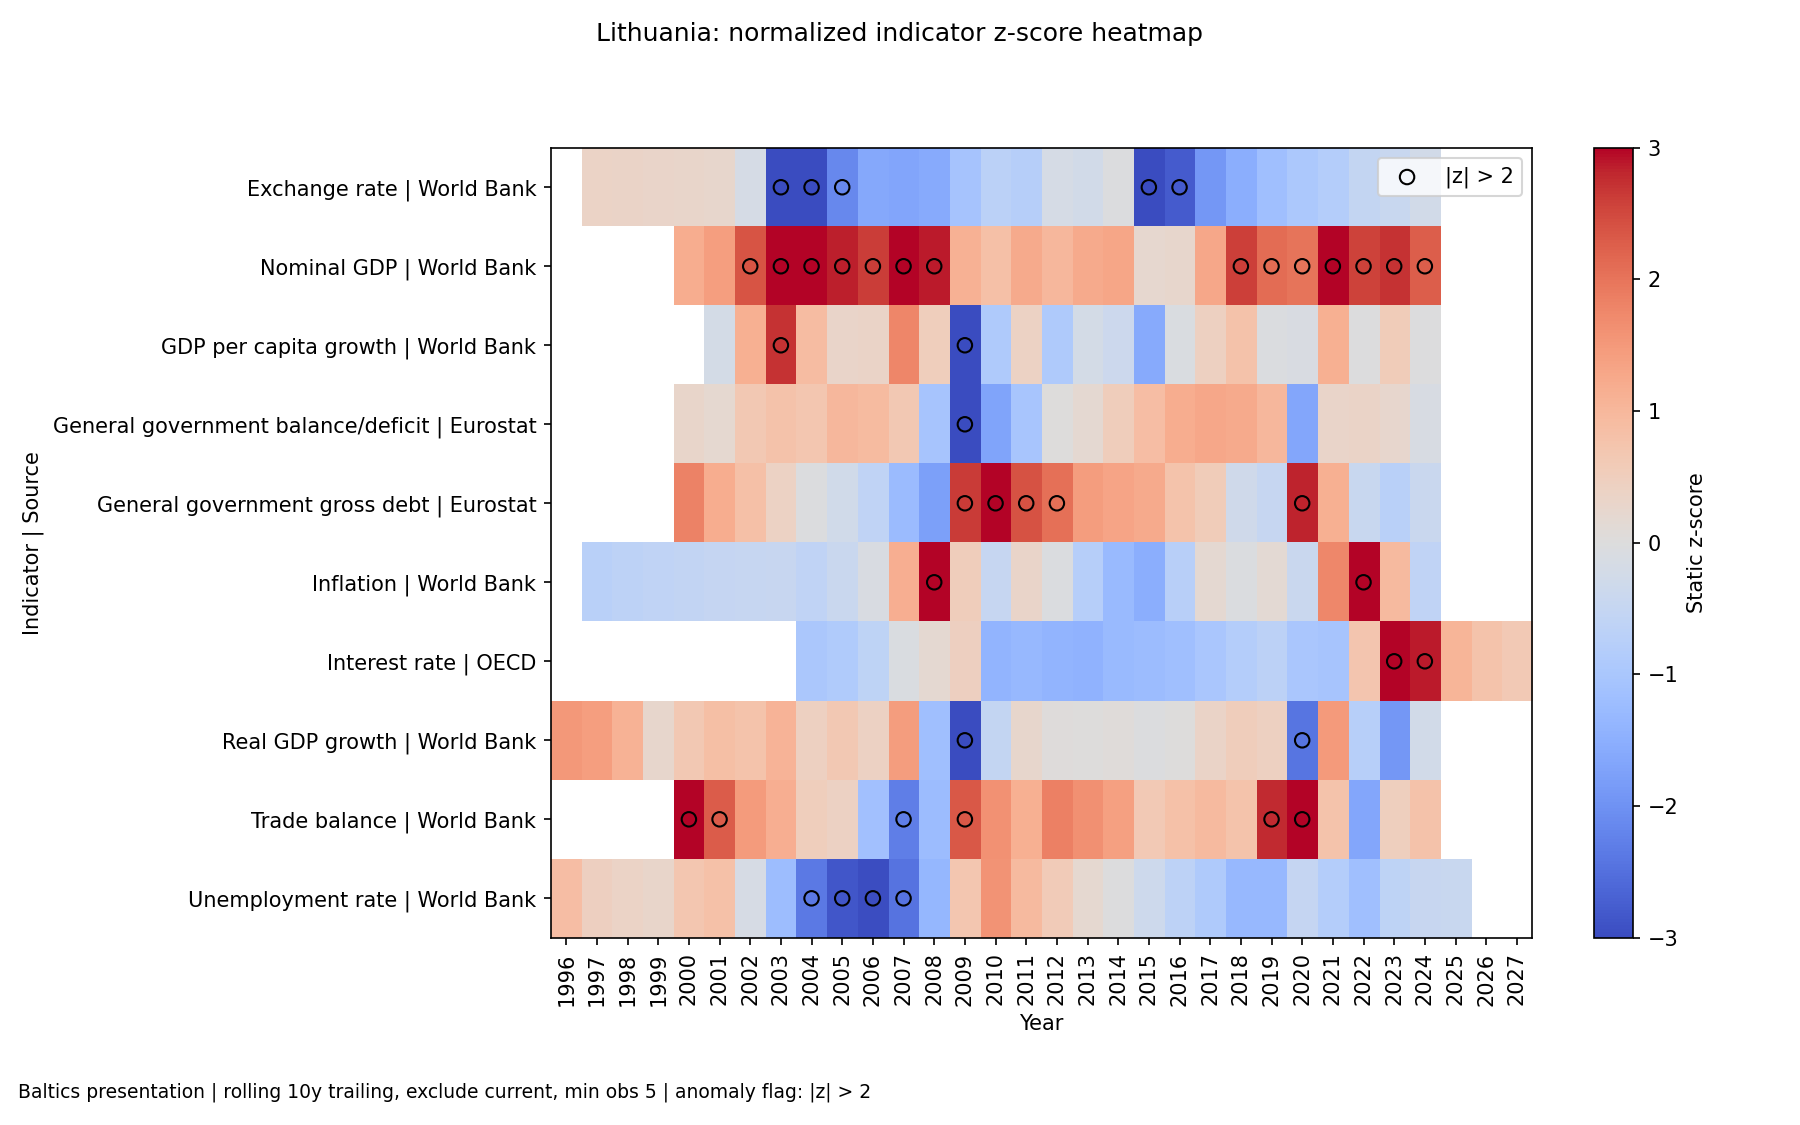

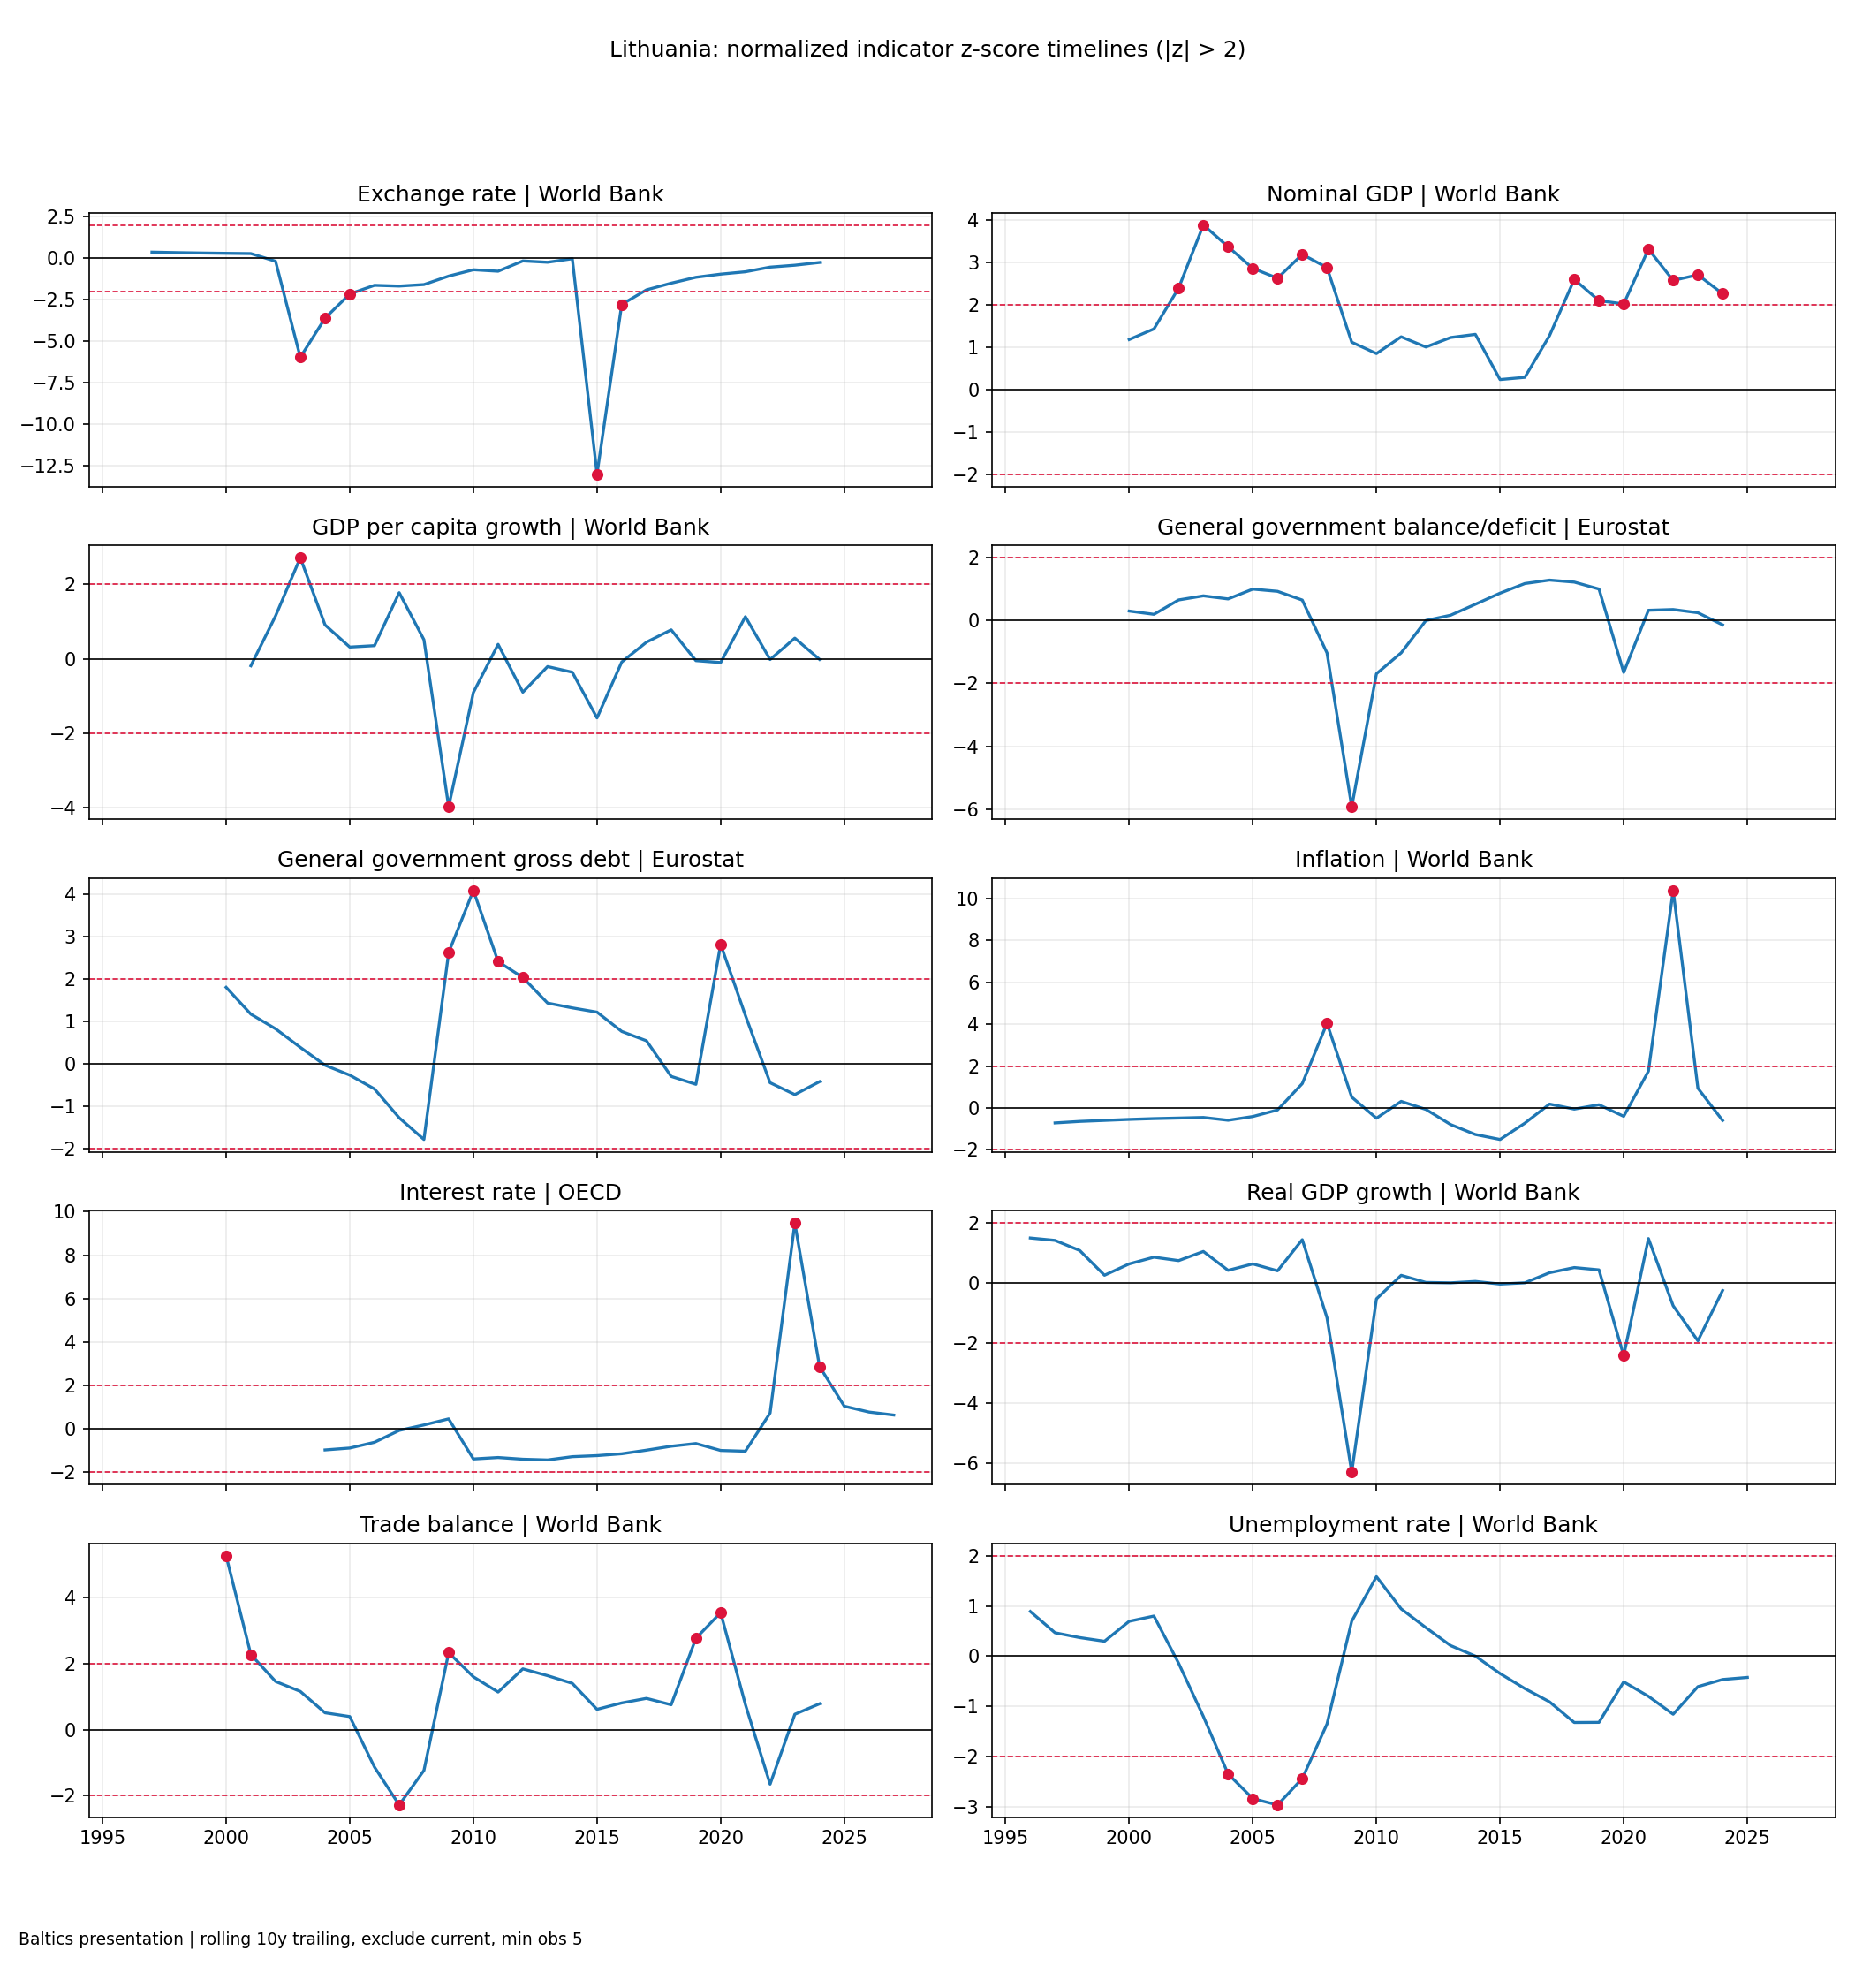

In [12]:
_lt_presentation_context = _render_country_presentation_section("LT", view_config=presentation_view_config)


### Latvia


**Country:** Latvia (LV)\n- View: Presentation view\n- Region label: Baltics presentation\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5\n- Transformation: Transformation active: GDP per capita growth, Real GDP growth\n- Presentation curation: hidden original level GDP panels where transformed growth series were available (`gdp_per_capita`, `real_gdp`).

**Selected sources used in presentation charts**

,Indicator,Source
0,Exchange rate,World Bank
1,GDP per capita growth,World Bank
2,General government balance/deficit,Eurostat
3,General government gross debt,Eurostat
4,Inflation,World Bank
5,Interest rate,OECD
6,Nominal GDP,World Bank
7,Real GDP growth,World Bank
8,Trade balance,World Bank
9,Unemployment rate,World Bank


**Presentation charts**

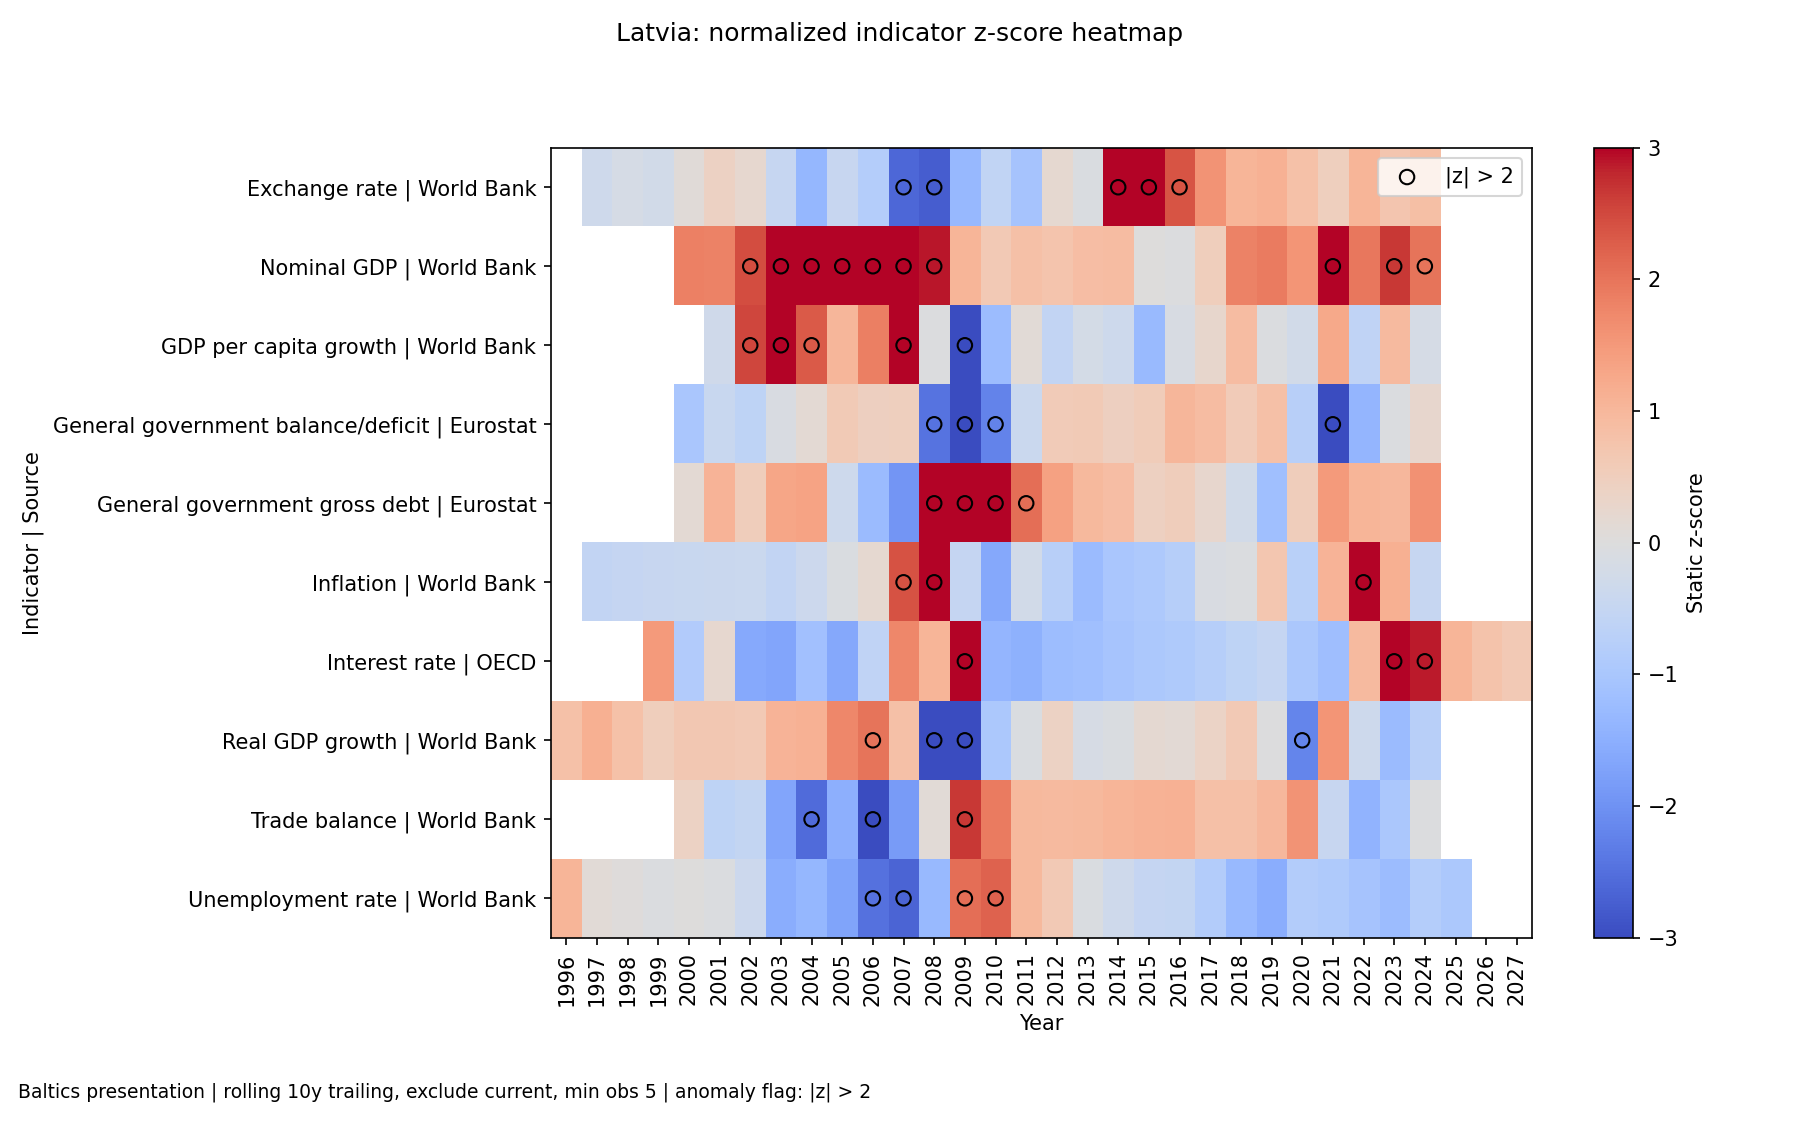

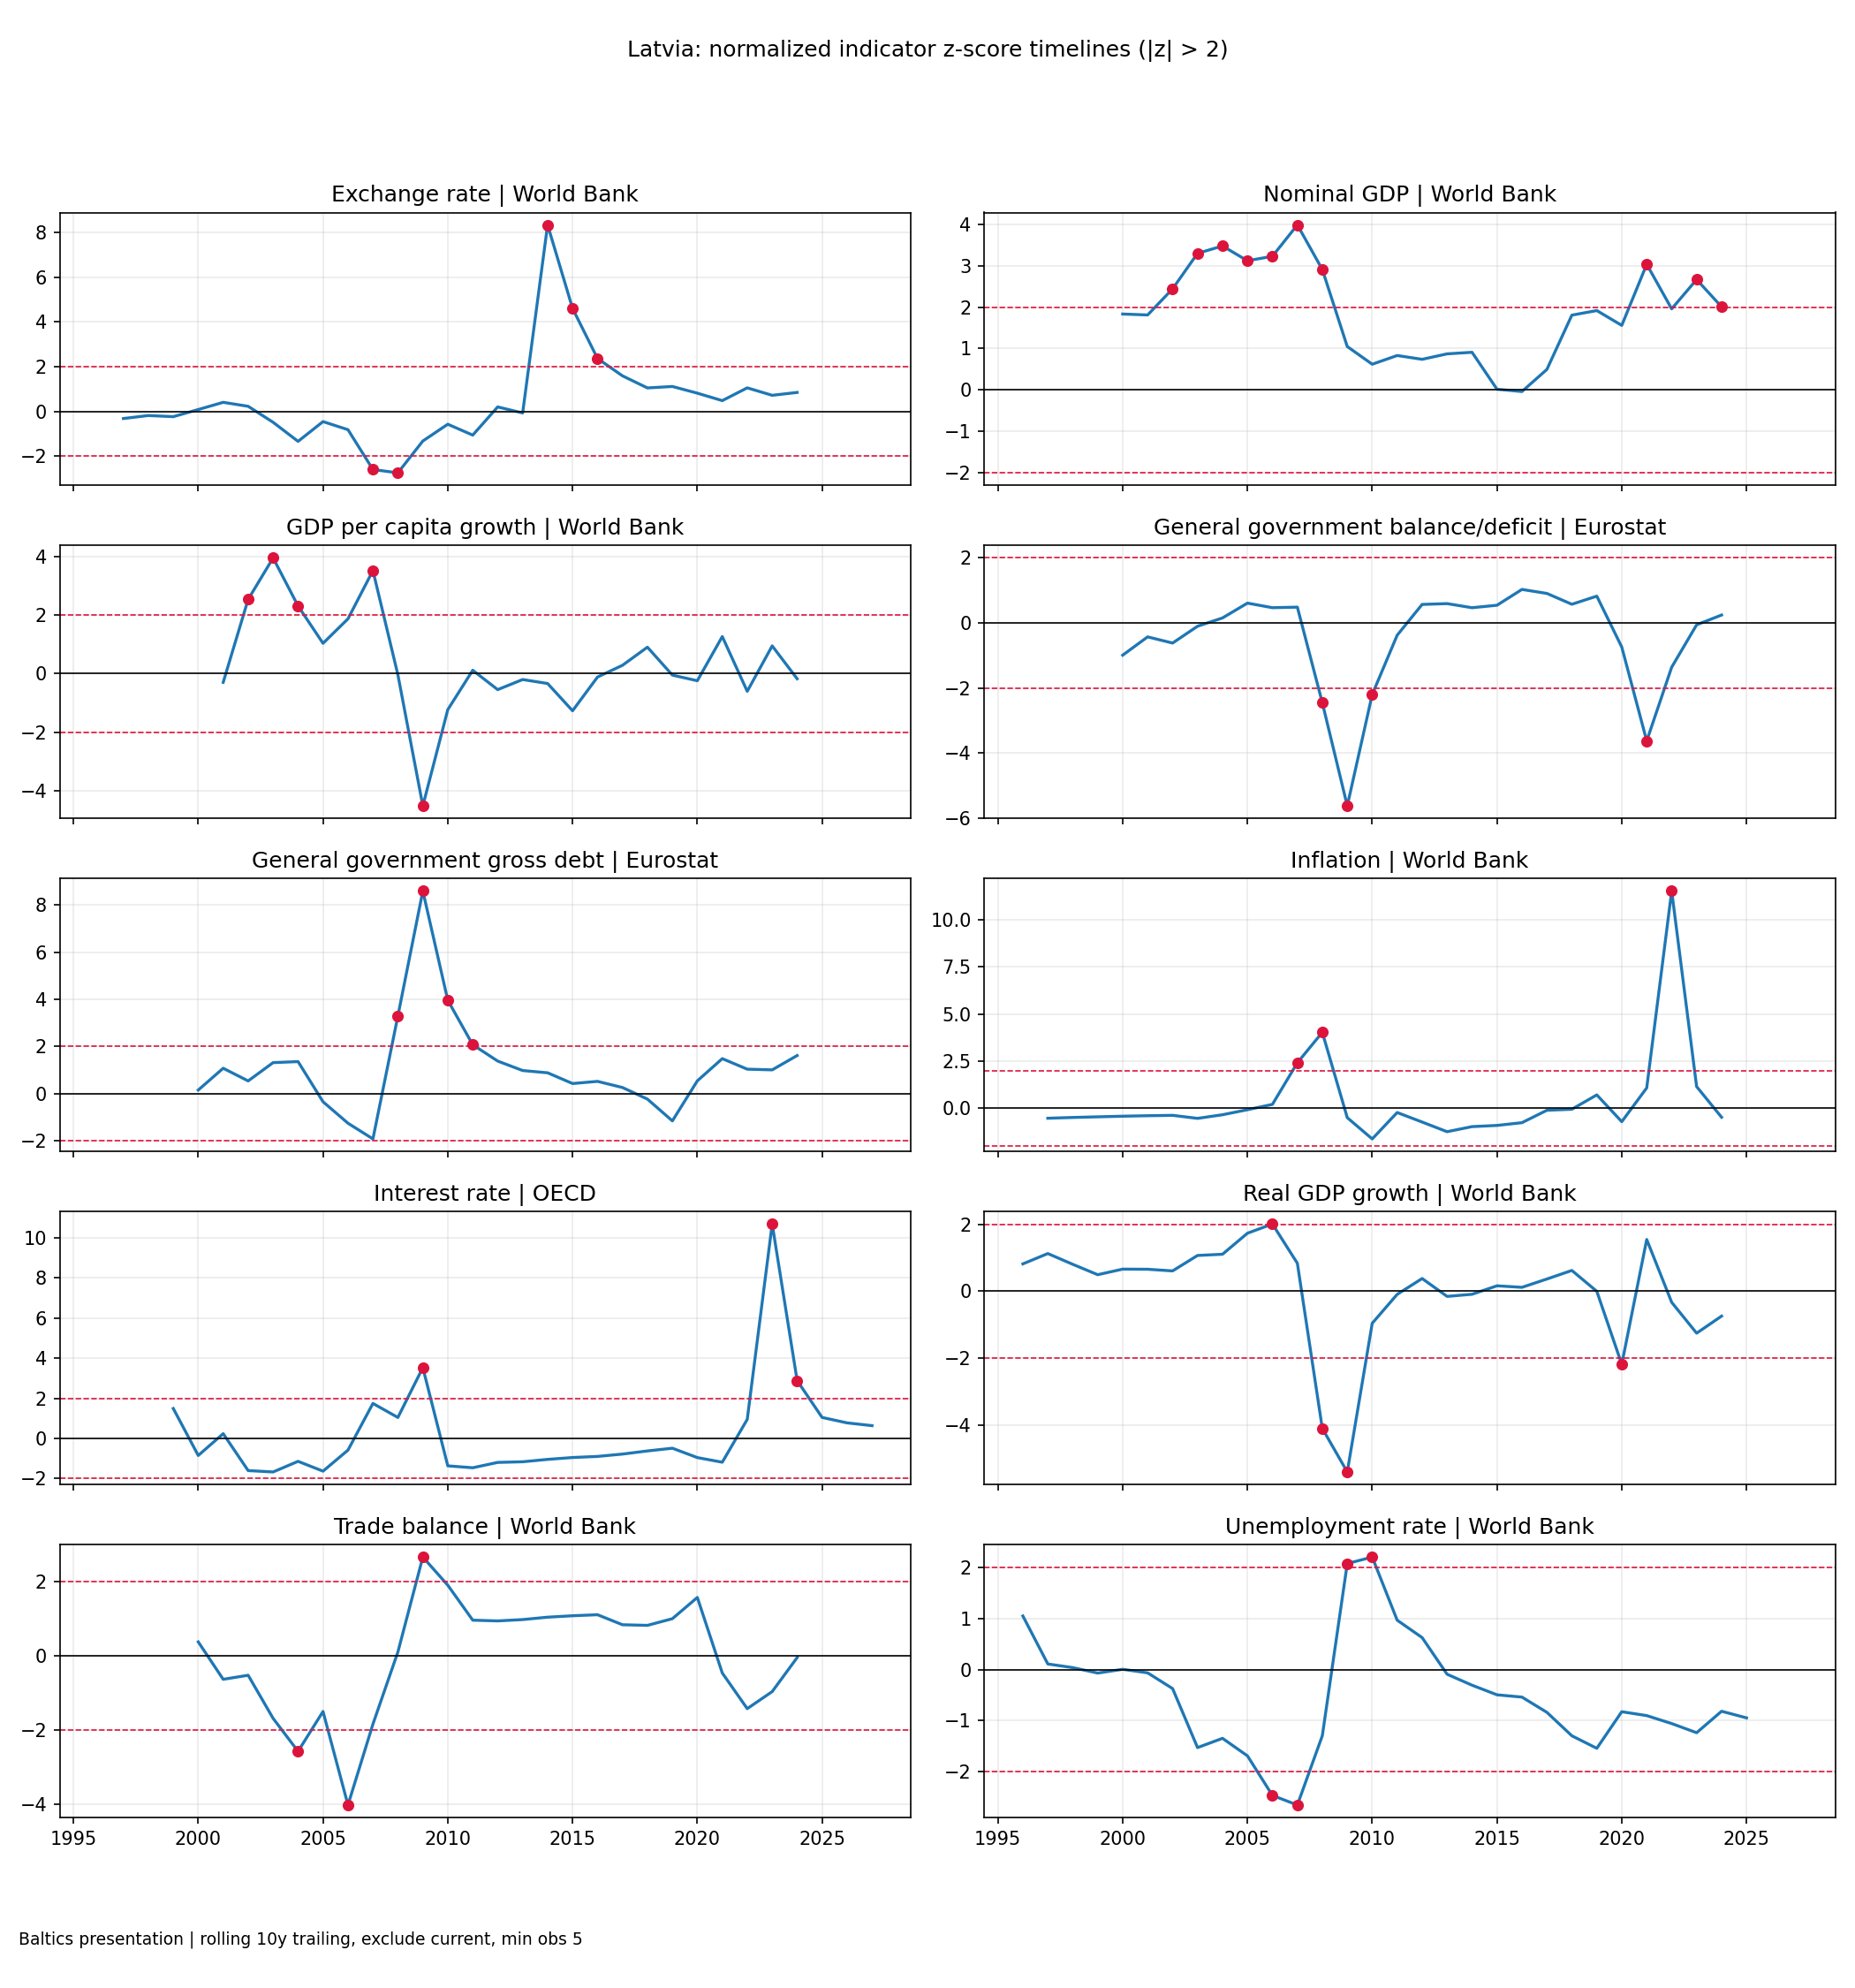

In [13]:
_lv_presentation_context = _render_country_presentation_section("LV", view_config=presentation_view_config)


### Estonia


**Country:** Estonia (EE)\n- View: Presentation view\n- Region label: Baltics presentation\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5\n- Transformation: Transformation active: GDP per capita growth, Real GDP growth\n- Presentation curation: hidden original level GDP panels where transformed growth series were available (`gdp_per_capita`, `real_gdp`).

**Selected sources used in presentation charts**

,Indicator,Source
0,Exchange rate,World Bank
1,GDP per capita growth,World Bank
2,General government balance/deficit,Eurostat
3,General government gross debt,Eurostat
4,Inflation,IMF
5,Interest rate,OECD
6,Nominal GDP,World Bank
7,Real GDP growth,World Bank
8,Trade balance,World Bank
9,Unemployment rate,World Bank


**Presentation charts**

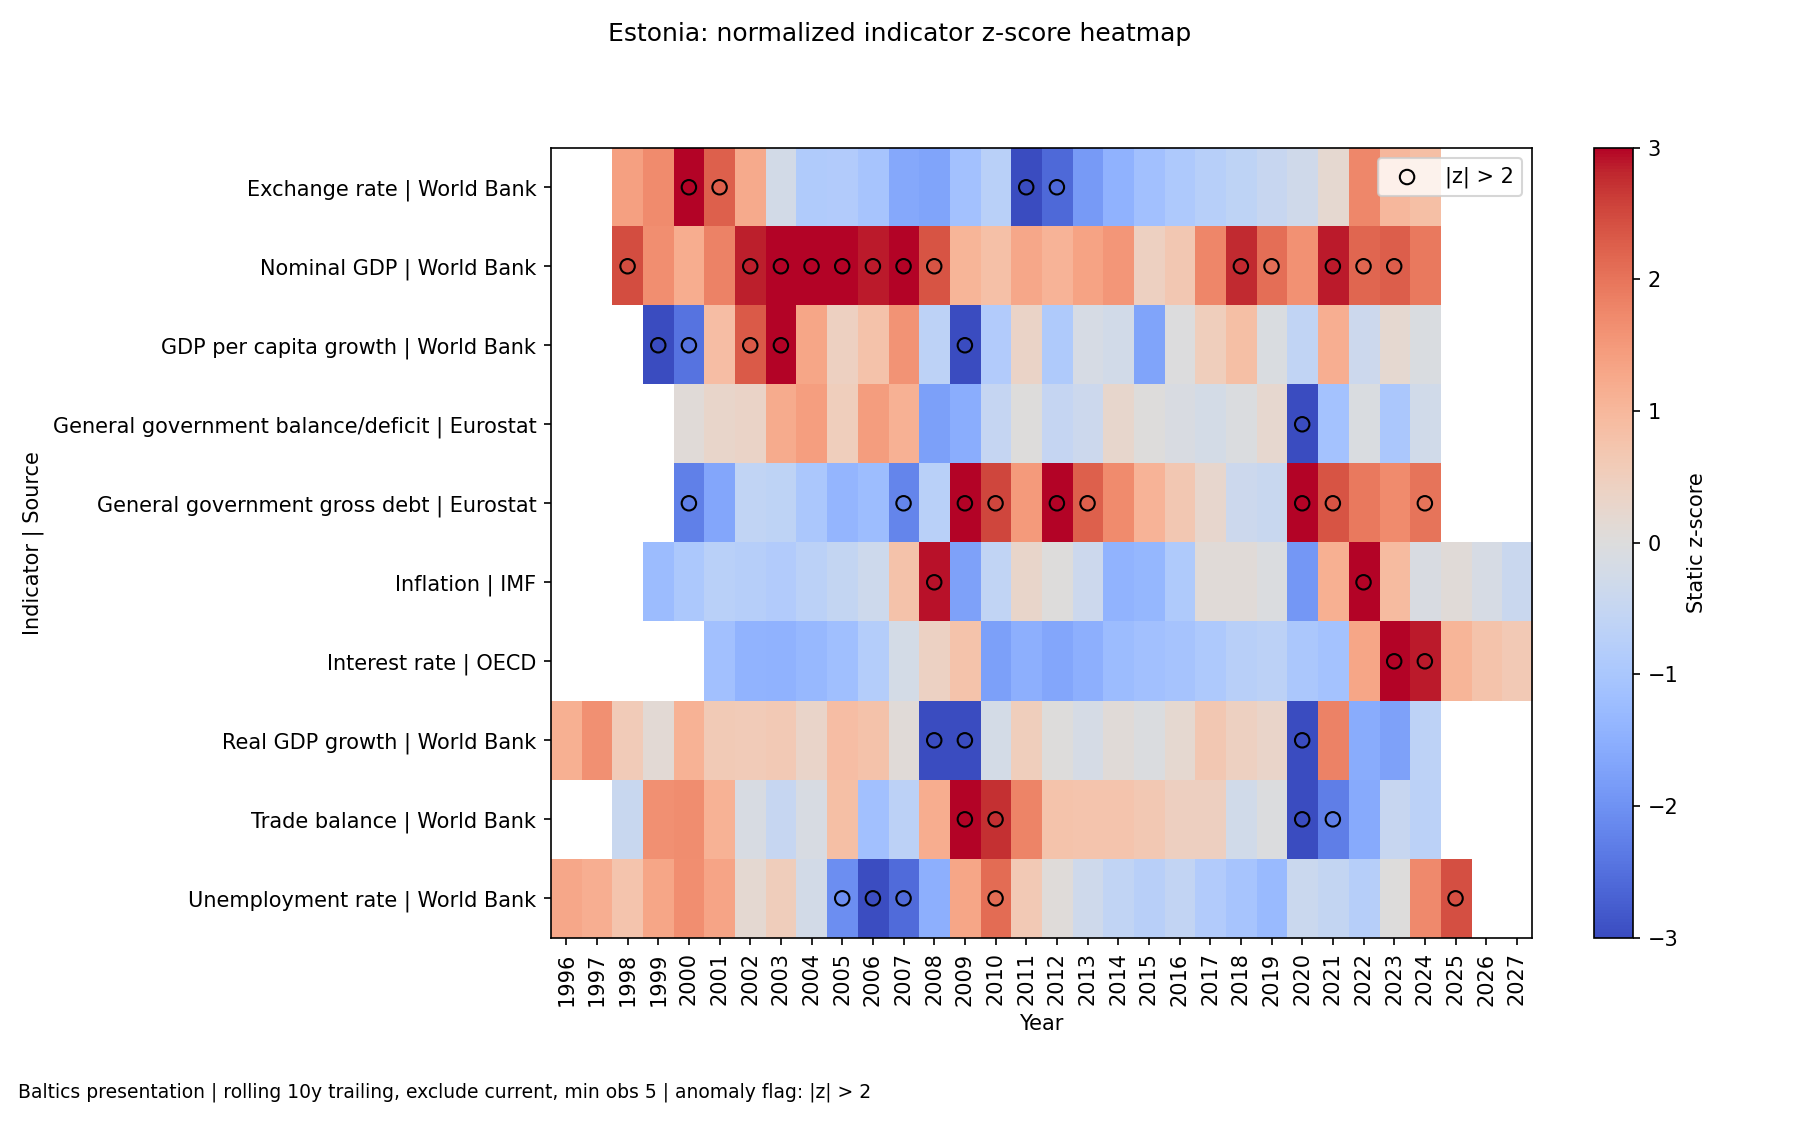

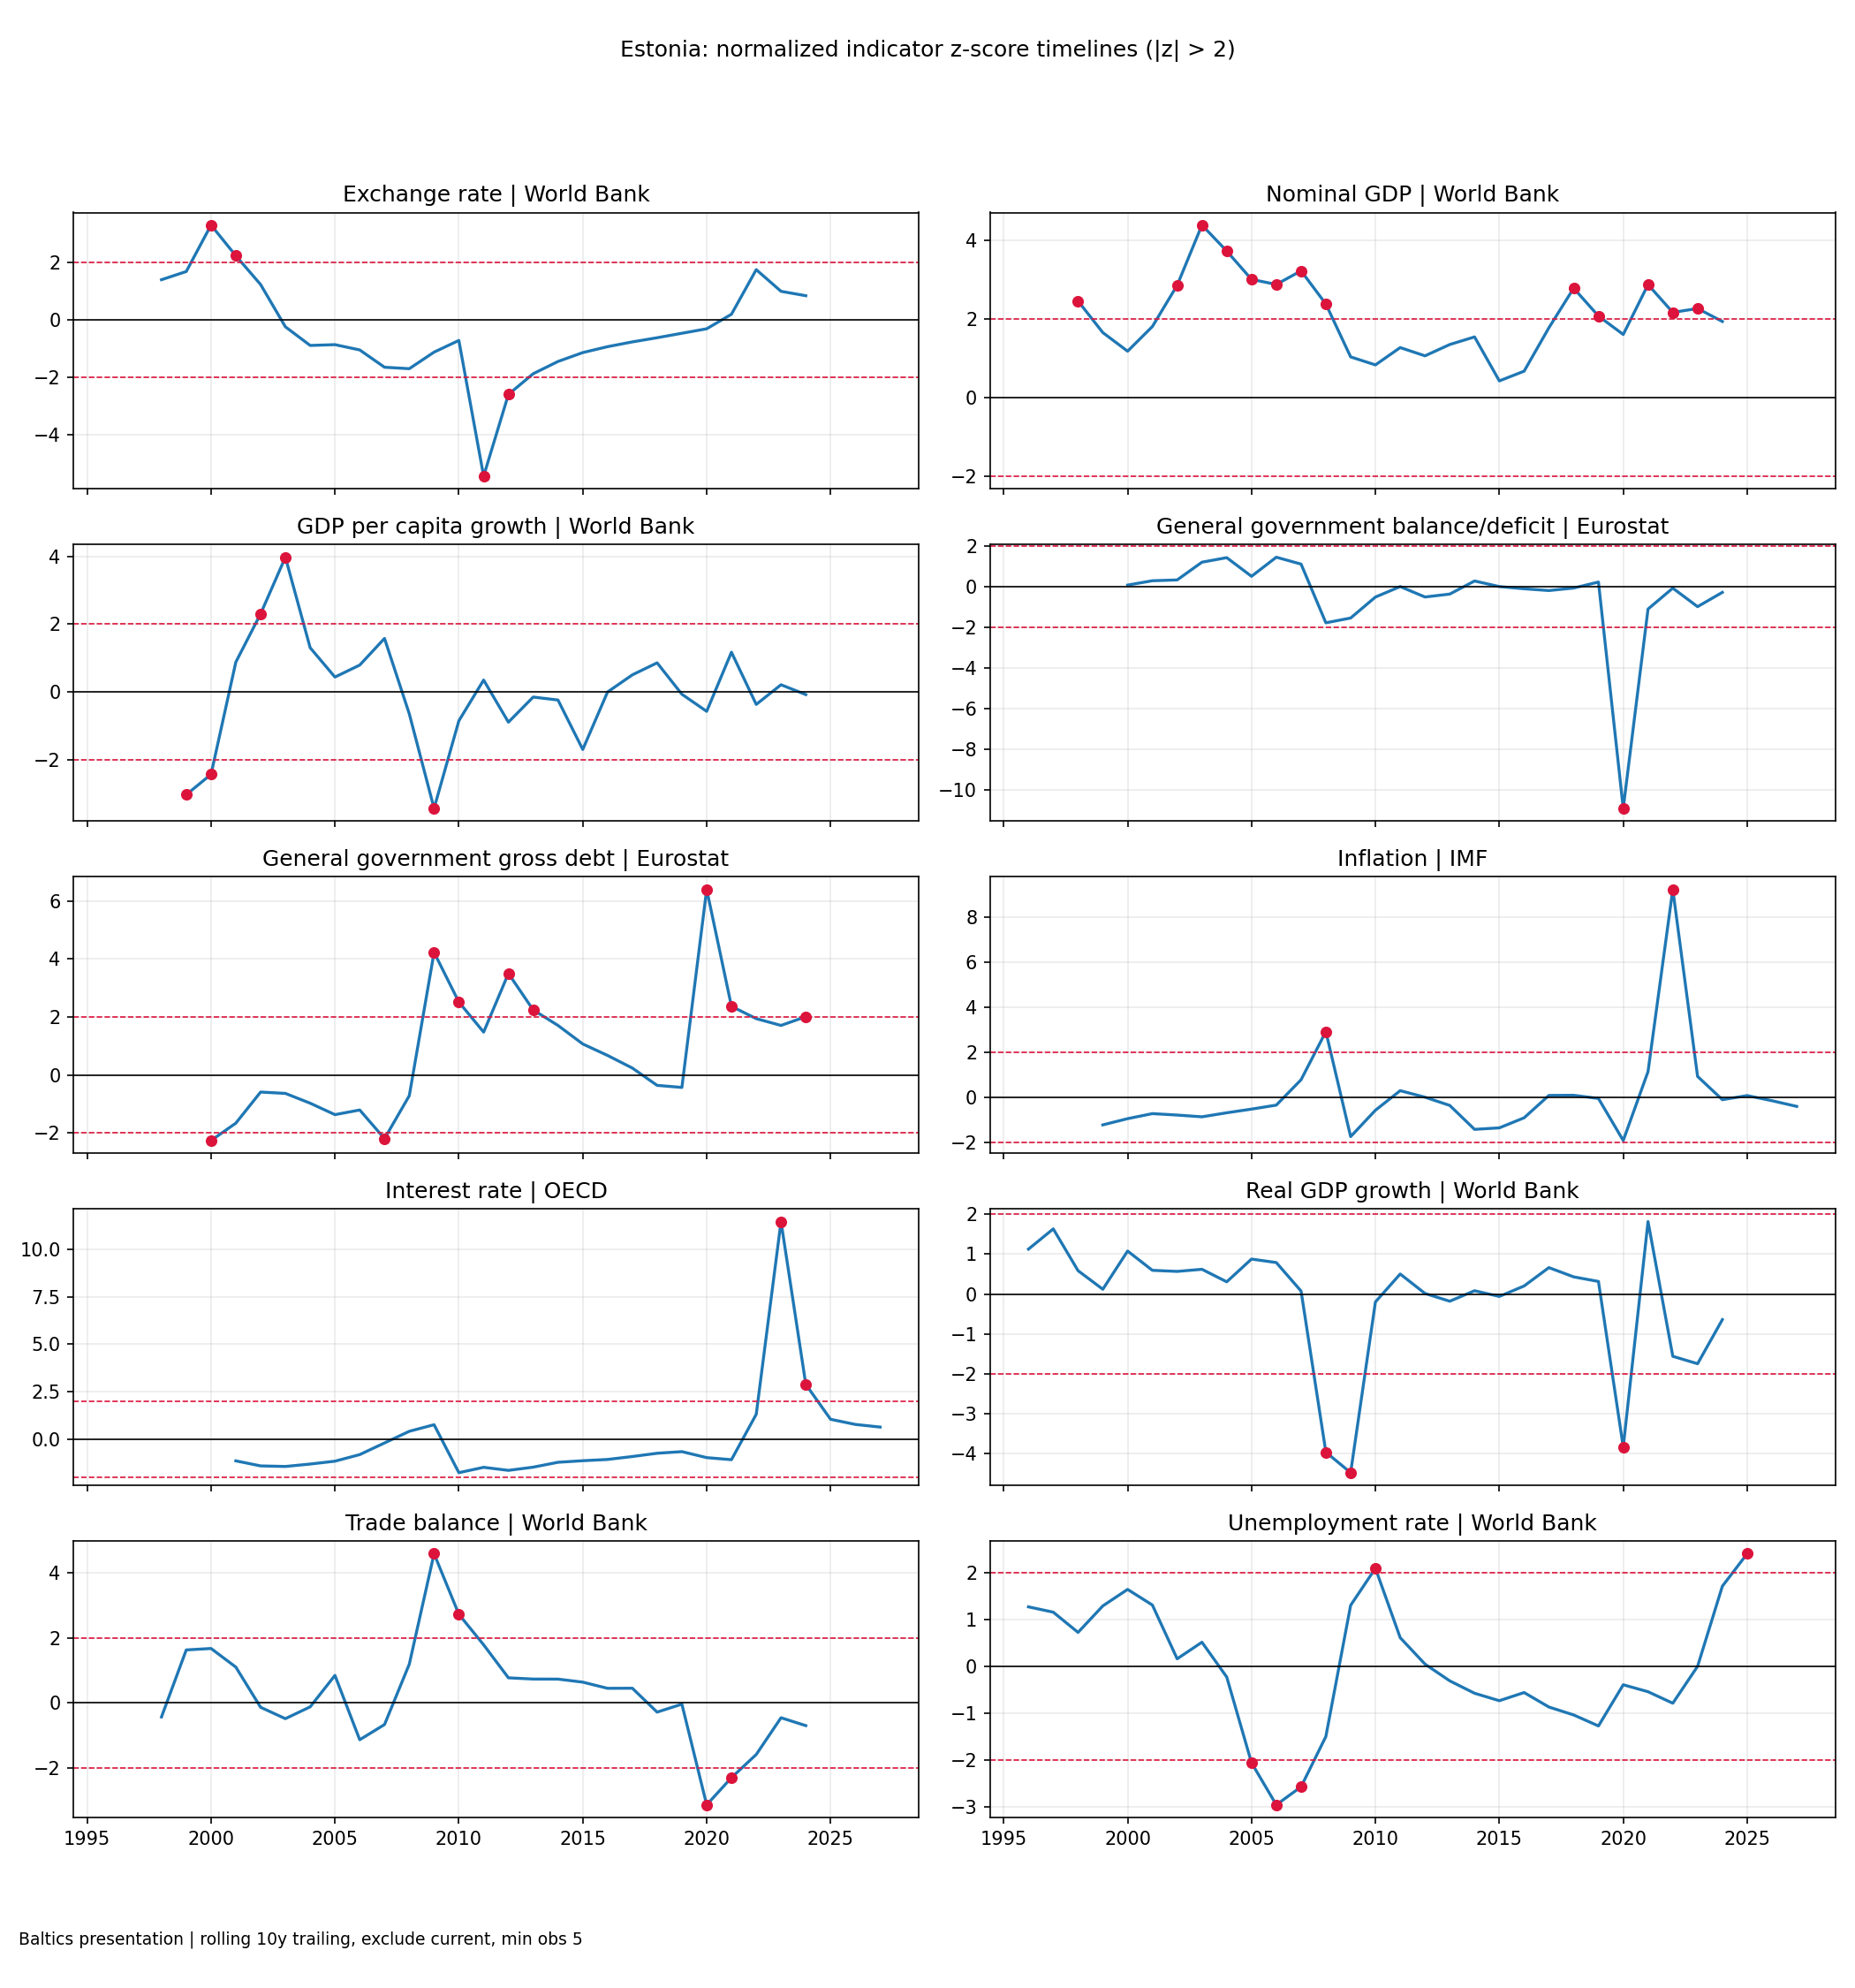

In [14]:
_ee_presentation_context = _render_country_presentation_section("EE", view_config=presentation_view_config)


## Methodology view

Use this section for QA, peer review, and provenance checks.

It keeps the mixed-mode normalization setup visible and adds override summaries, selected-source provenance, anomaly tables, and the underlying dynamic charts so each result can be traced back to its configuration and source data.


### Lithuania


**Country:** Lithuania (LT)\n- View: Methodology view\n- Region label: Baltics methodology\n- Render mode: dynamic\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5 | 3 indicator overrides\n- Transformation: No transformation requested.

**Normalization overrides**

,Indicator,Mode,Summary
0,GDP per capita,static baseline,"Static baseline from 1999, min obs 3"
1,Nominal GDP,static baseline,"Static baseline from 1999, min obs 3"
2,Real GDP,static baseline,"Static baseline from 1999, min obs 3"


**Selected source provenance**

,Indicator,Source,Mapping,Obs,Years,Normalization
0,Exchange rate,World Bank,exact,33,1992-2024,"Rolling 10y, exclude current"
1,GDP per capita,World Bank,exact,30,1995-2024,Static from 1999
2,General government balance/deficit,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
3,General government gross debt,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
4,Inflation,World Bank,exact,33,1992-2024,"Rolling 10y, exclude current"
5,Interest rate,OECD,proxy,29,1999-2027,"Rolling 10y, exclude current"
6,Nominal GDP,World Bank,exact,30,1995-2024,Static from 1999
7,Real GDP,World Bank,exact,35,1990-2024,Static from 1999
8,Trade balance,World Bank,exact,30,1995-2024,"Rolling 10y, exclude current"
9,Unemployment rate,World Bank,exact,35,1991-2025,"Rolling 10y, exclude current"


**Flagged anomalies (`|z| > 2`)**

,Indicator,Source,Year,Value,Z-score
0,Exchange rate,World Bank,2015,0.901296,-12.987
1,Inflation,World Bank,2022,19.705,10.383
2,Interest rate,OECD,2023,3.4308,9.474
3,Exchange rate,World Bank,2003,3.06087,-5.962
4,General government balance/deficit,Eurostat,2009,-9.1,-5.928
5,Trade balance,World Bank,2000,-6.17683,5.265
6,General government gross debt,Eurostat,2010,36.7,4.091
7,Inflation,World Bank,2008,10.9259,4.041
8,Exchange rate,World Bank,2004,2.78059,-3.610
9,Trade balance,World Bank,2020,9.07281,3.546


**Methodology charts**

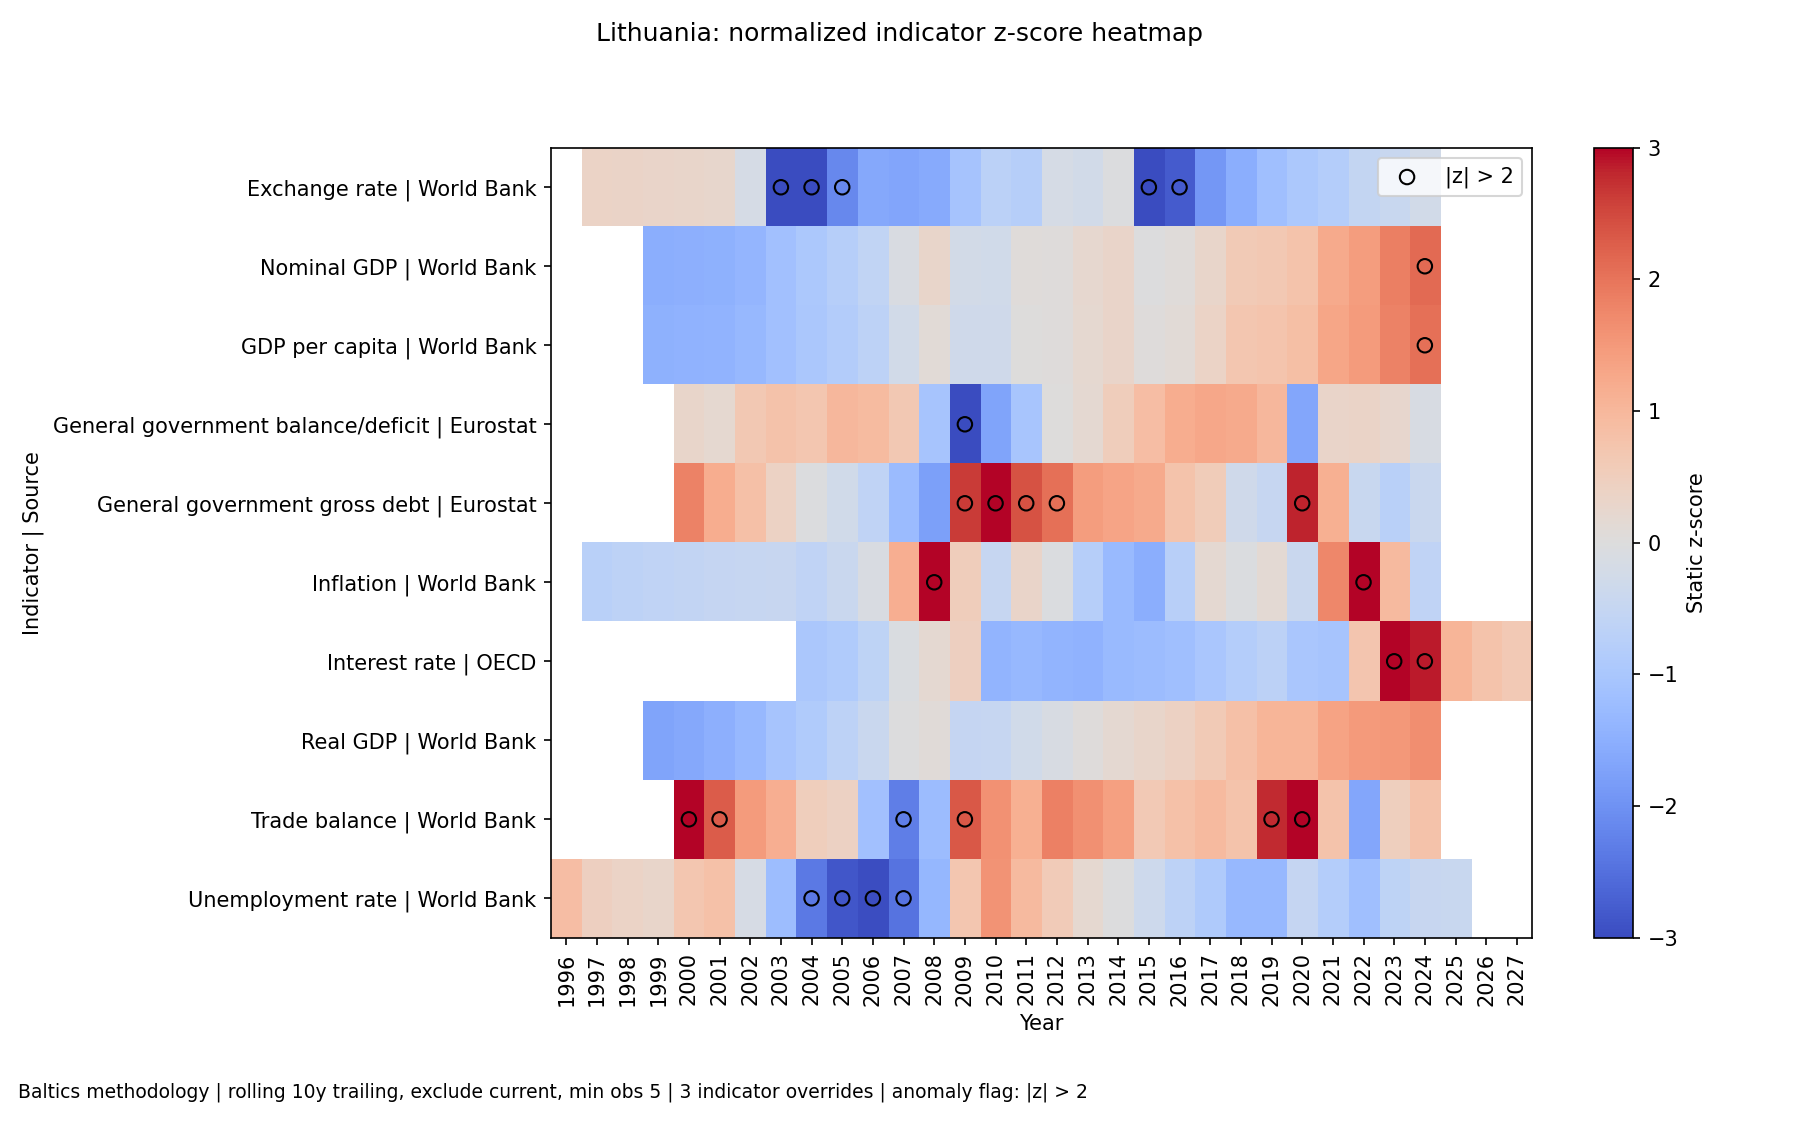

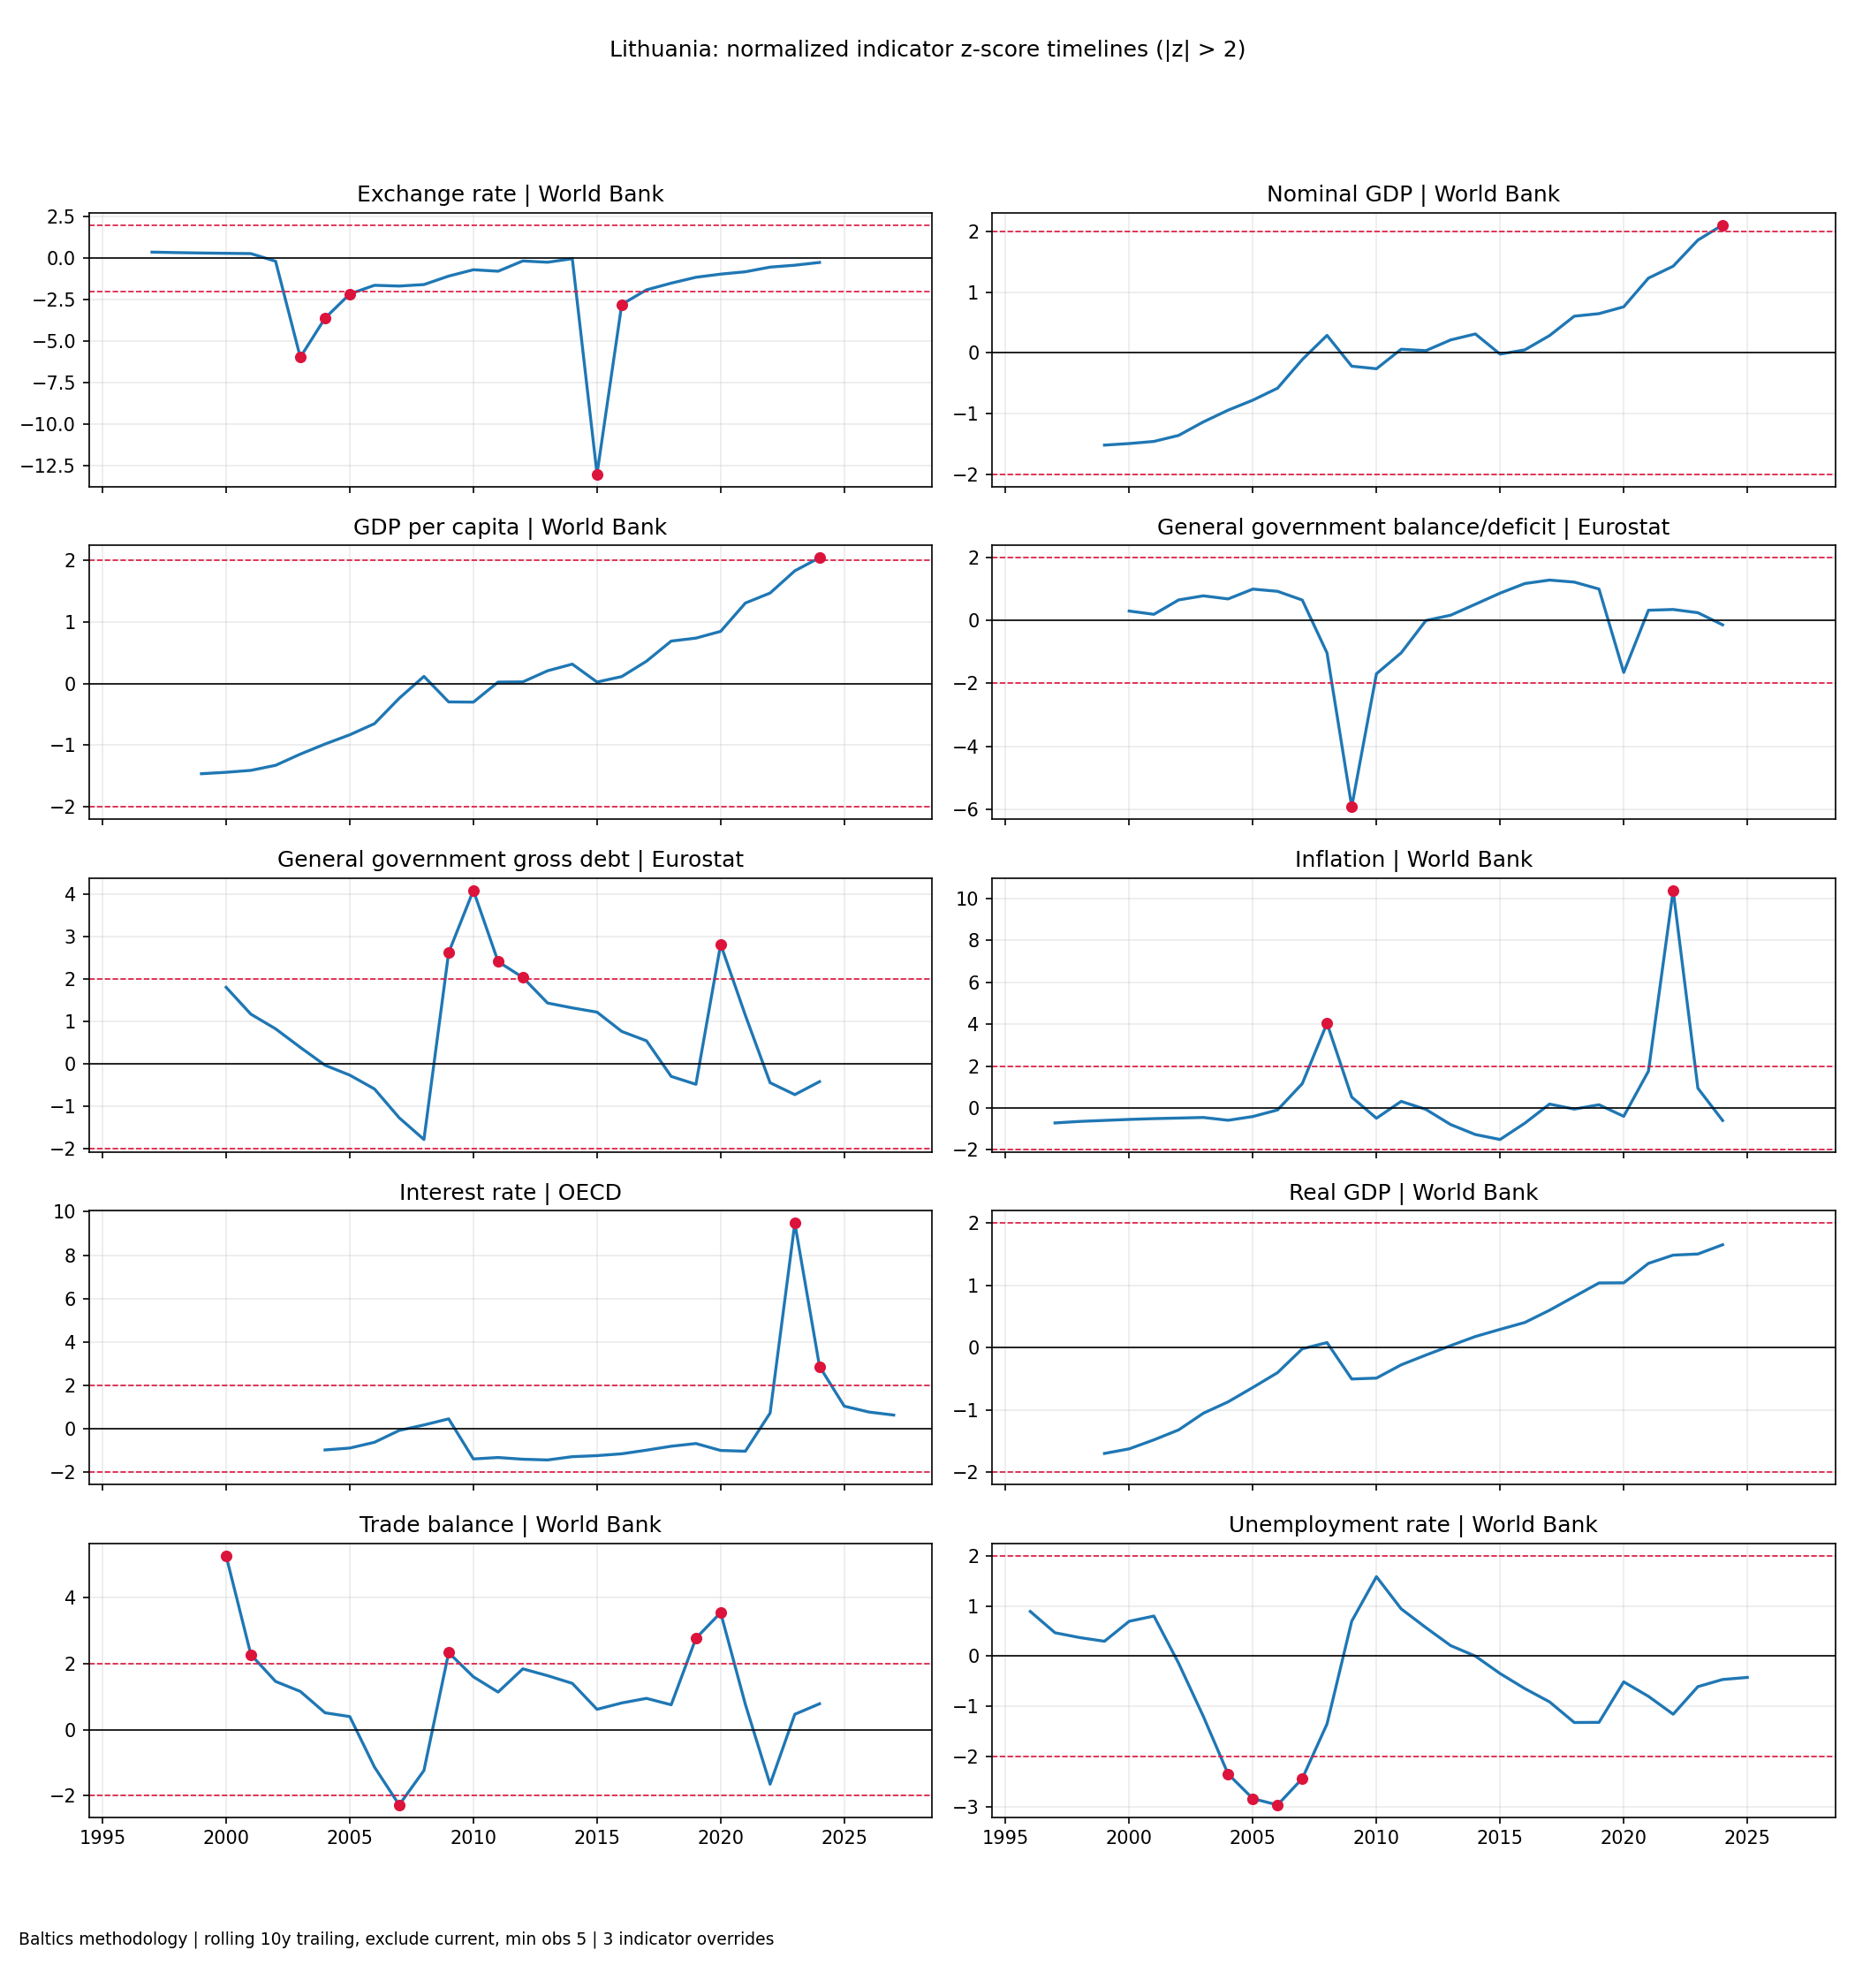

In [15]:
_lt_methodology_context = _render_country_methodology_section("LT", view_config=methodology_view_config)


### Latvia


**Country:** Latvia (LV)\n- View: Methodology view\n- Region label: Baltics methodology\n- Render mode: dynamic\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5 | 3 indicator overrides\n- Transformation: No transformation requested.

**Normalization overrides**

,Indicator,Mode,Summary
0,GDP per capita,static baseline,"Static baseline from 1999, min obs 3"
1,Nominal GDP,static baseline,"Static baseline from 1999, min obs 3"
2,Real GDP,static baseline,"Static baseline from 1999, min obs 3"


**Selected source provenance**

,Indicator,Source,Mapping,Obs,Years,Normalization
0,Exchange rate,World Bank,exact,33,1992-2024,"Rolling 10y, exclude current"
1,GDP per capita,World Bank,exact,30,1995-2024,Static from 1999
2,General government balance/deficit,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
3,General government gross debt,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
4,Inflation,World Bank,exact,33,1992-2024,"Rolling 10y, exclude current"
5,Interest rate,OECD,proxy,34,1994-2027,"Rolling 10y, exclude current"
6,Nominal GDP,World Bank,exact,30,1995-2024,Static from 1999
7,Real GDP,World Bank,exact,35,1990-2024,Static from 1999
8,Trade balance,World Bank,exact,30,1995-2024,"Rolling 10y, exclude current"
9,Unemployment rate,World Bank,exact,35,1991-2025,"Rolling 10y, exclude current"


**Flagged anomalies (`|z| > 2`)**

,Indicator,Source,Year,Value,Z-score
0,Inflation,World Bank,2022,17.3103,11.535
1,Interest rate,OECD,2023,3.4308,10.695
2,General government gross debt,Eurostat,2009,38,8.591
3,Exchange rate,World Bank,2014,0.752728,8.350
4,General government balance/deficit,Eurostat,2009,-9.8,-5.632
5,Exchange rate,World Bank,2015,0.901296,4.610
6,Inflation,World Bank,2008,15.4023,4.025
7,Trade balance,World Bank,2006,-21.7892,-4.017
8,General government gross debt,Eurostat,2010,48.6,3.955
9,General government balance/deficit,Eurostat,2021,-7.2,-3.633


**Methodology charts**

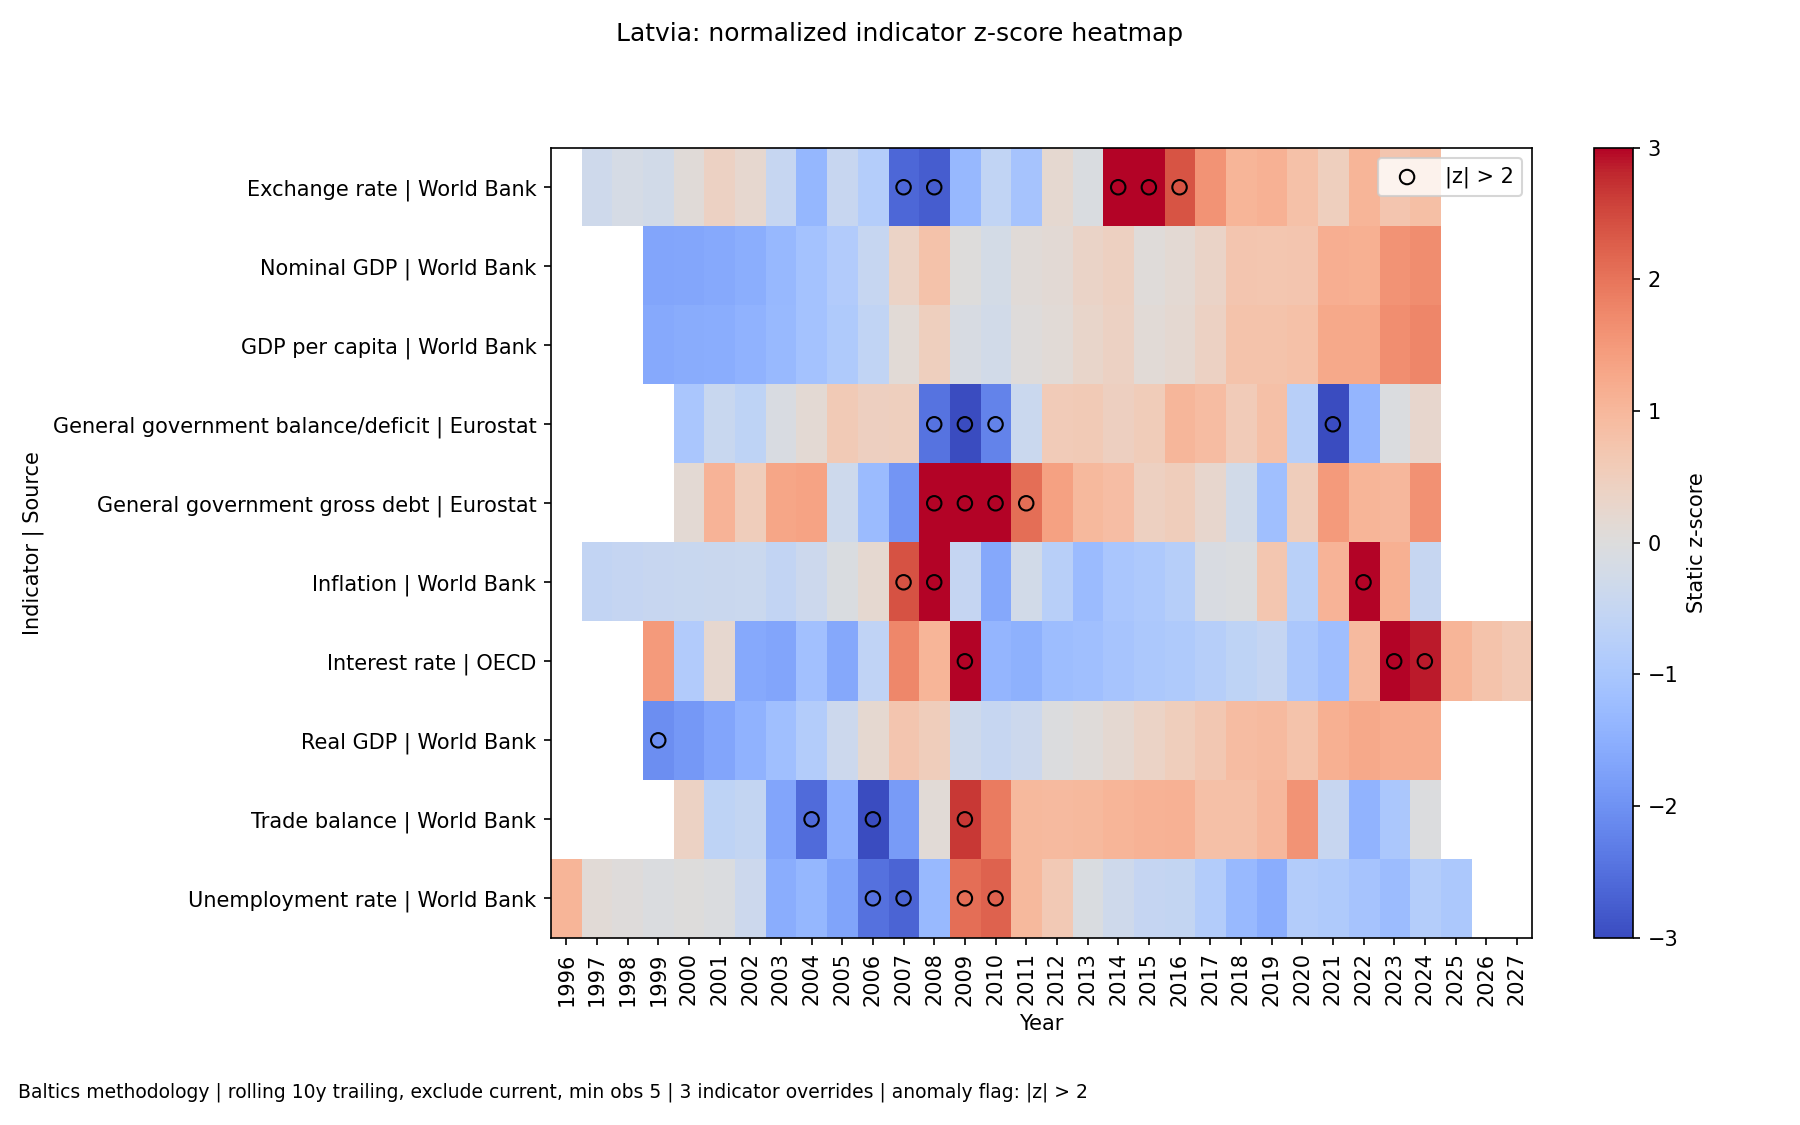

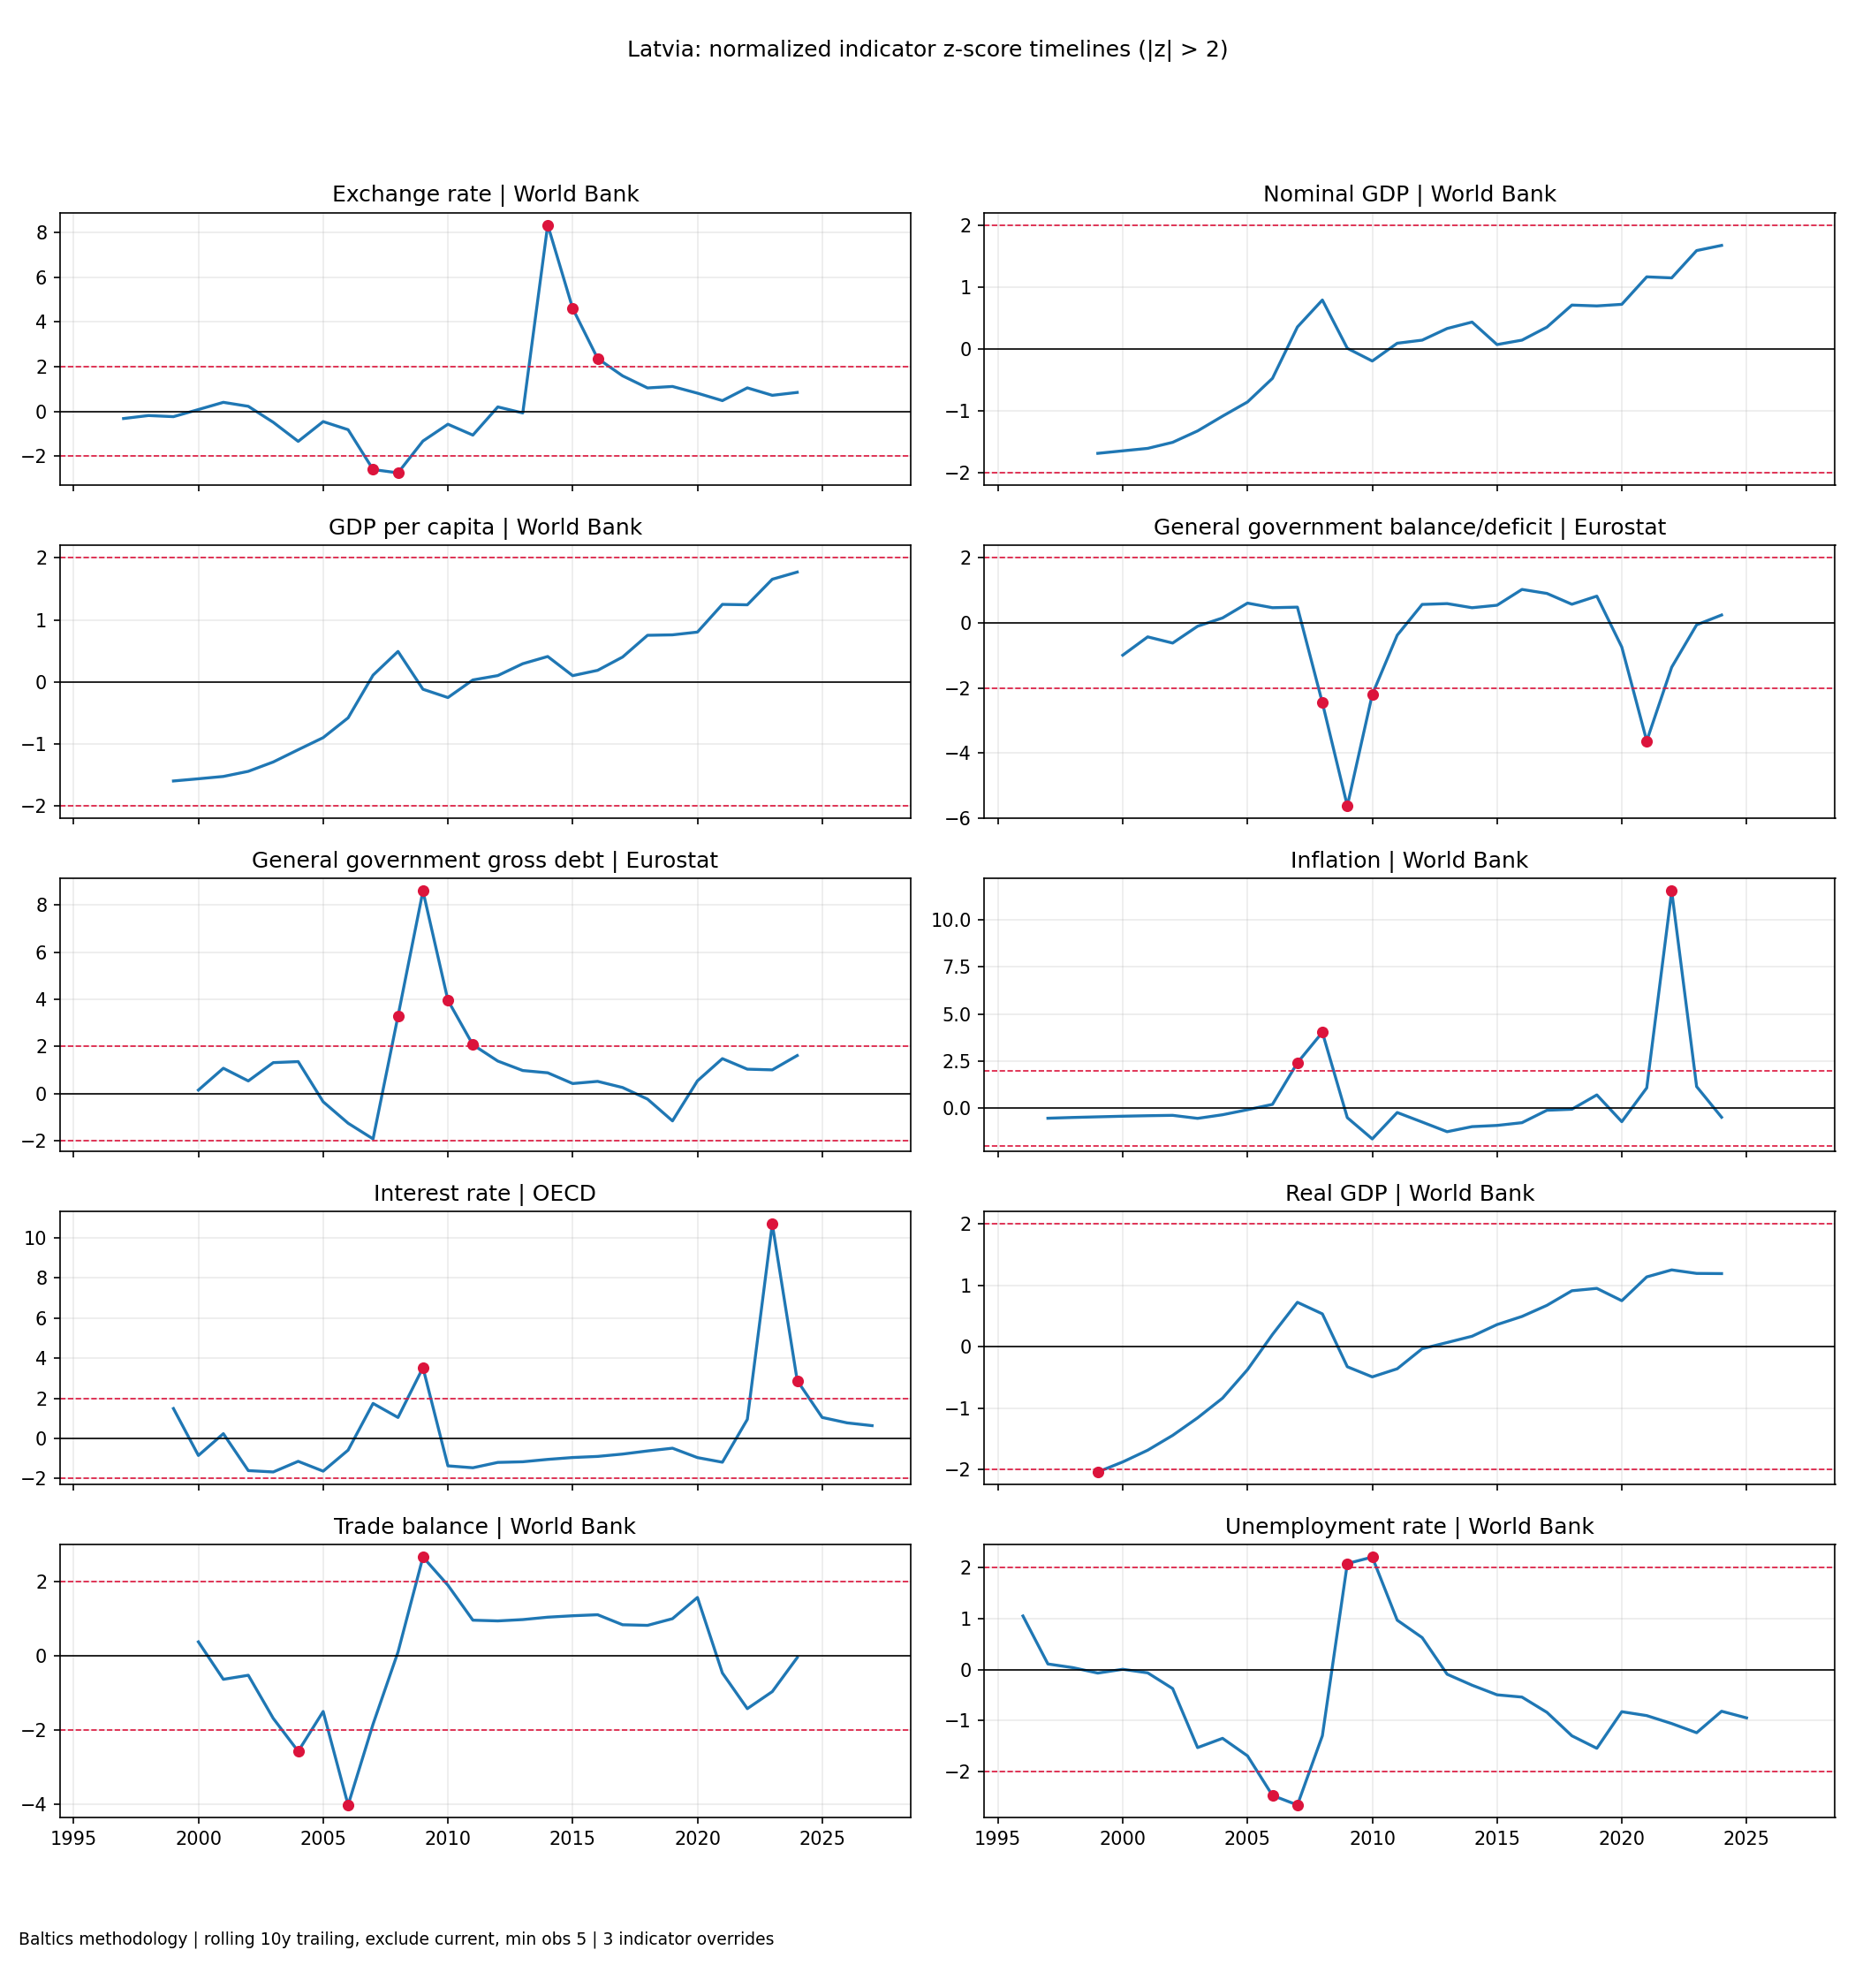

In [16]:
_lv_methodology_context = _render_country_methodology_section("LV", view_config=methodology_view_config)


### Estonia


**Country:** Estonia (EE)\n- View: Methodology view\n- Region label: Baltics methodology\n- Render mode: dynamic\n- Normalization: Rolling trailing, 10y, exclude current, min obs 5 | 3 indicator overrides\n- Transformation: No transformation requested.

**Normalization overrides**

,Indicator,Mode,Summary
0,GDP per capita,static baseline,"Static baseline from 1999, min obs 3"
1,Nominal GDP,static baseline,"Static baseline from 1999, min obs 3"
2,Real GDP,static baseline,"Static baseline from 1999, min obs 3"


**Selected source provenance**

,Indicator,Source,Mapping,Obs,Years,Normalization
0,Exchange rate,World Bank,exact,32,1993-2024,"Rolling 10y, exclude current"
1,GDP per capita,World Bank,exact,32,1993-2024,Static from 1999
2,General government balance/deficit,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
3,General government gross debt,Eurostat,exact,30,1995-2024,"Rolling 10y, exclude current"
4,Inflation,IMF,proxy,34,1994-2027,"Rolling 10y, exclude current"
5,Interest rate,OECD,proxy,32,1996-2027,"Rolling 10y, exclude current"
6,Nominal GDP,World Bank,exact,32,1993-2024,Static from 1999
7,Real GDP,World Bank,exact,35,1990-2024,Static from 1999
8,Trade balance,World Bank,exact,32,1993-2024,"Rolling 10y, exclude current"
9,Unemployment rate,World Bank,exact,35,1991-2025,"Rolling 10y, exclude current"


**Flagged anomalies (`|z| > 2`)**

,Indicator,Source,Year,Value,Z-score
0,Interest rate,OECD,2023,3.4308,11.465
1,General government balance/deficit,Eurostat,2020,-5.4,-10.890
2,Inflation,IMF,2022,19.4,9.249
3,General government gross debt,Eurostat,2020,19.1,6.394
4,Exchange rate,World Bank,2011,0.718414,-5.431
5,Trade balance,World Bank,2009,4.96376,4.577
6,General government gross debt,Eurostat,2009,8,4.225
7,General government gross debt,Eurostat,2012,11.1,3.499
8,Exchange rate,World Bank,2000,16.9686,3.308
9,Trade balance,World Bank,2020,-1.08353,-3.122


**Methodology charts**

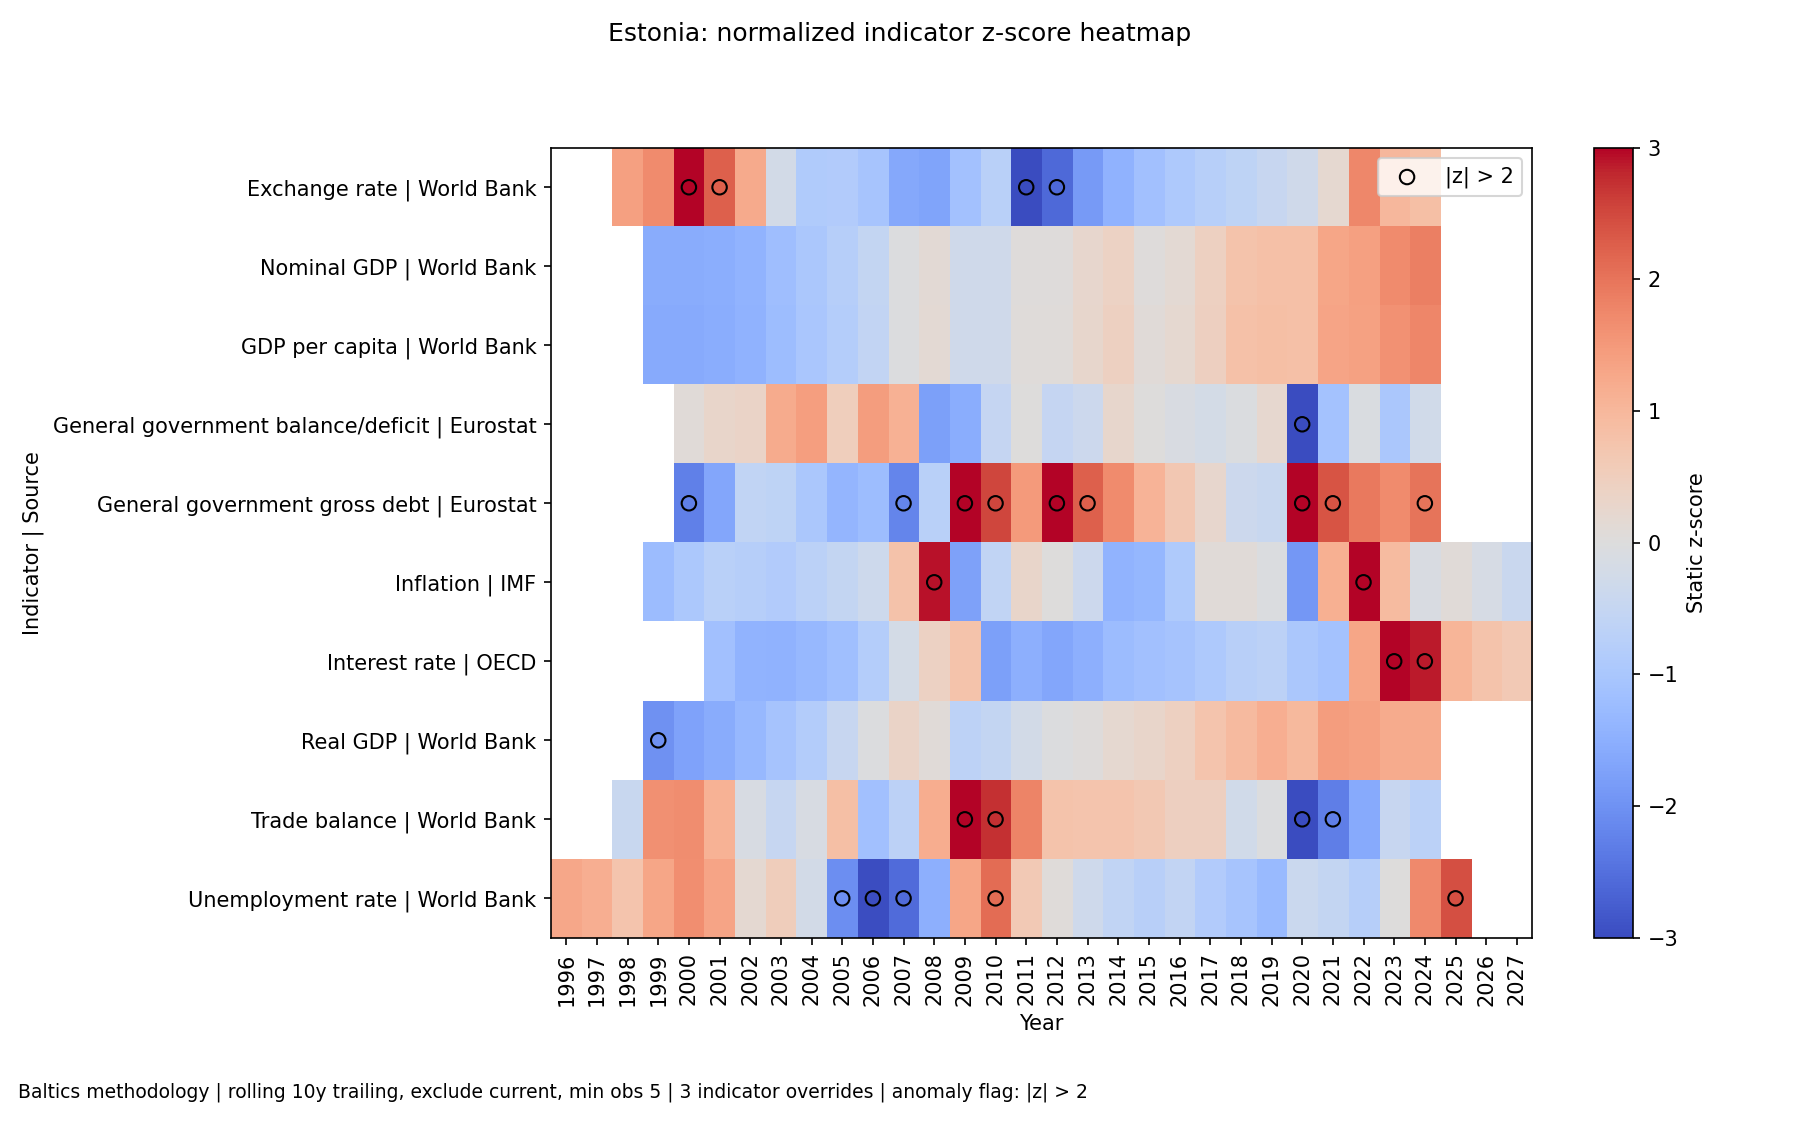

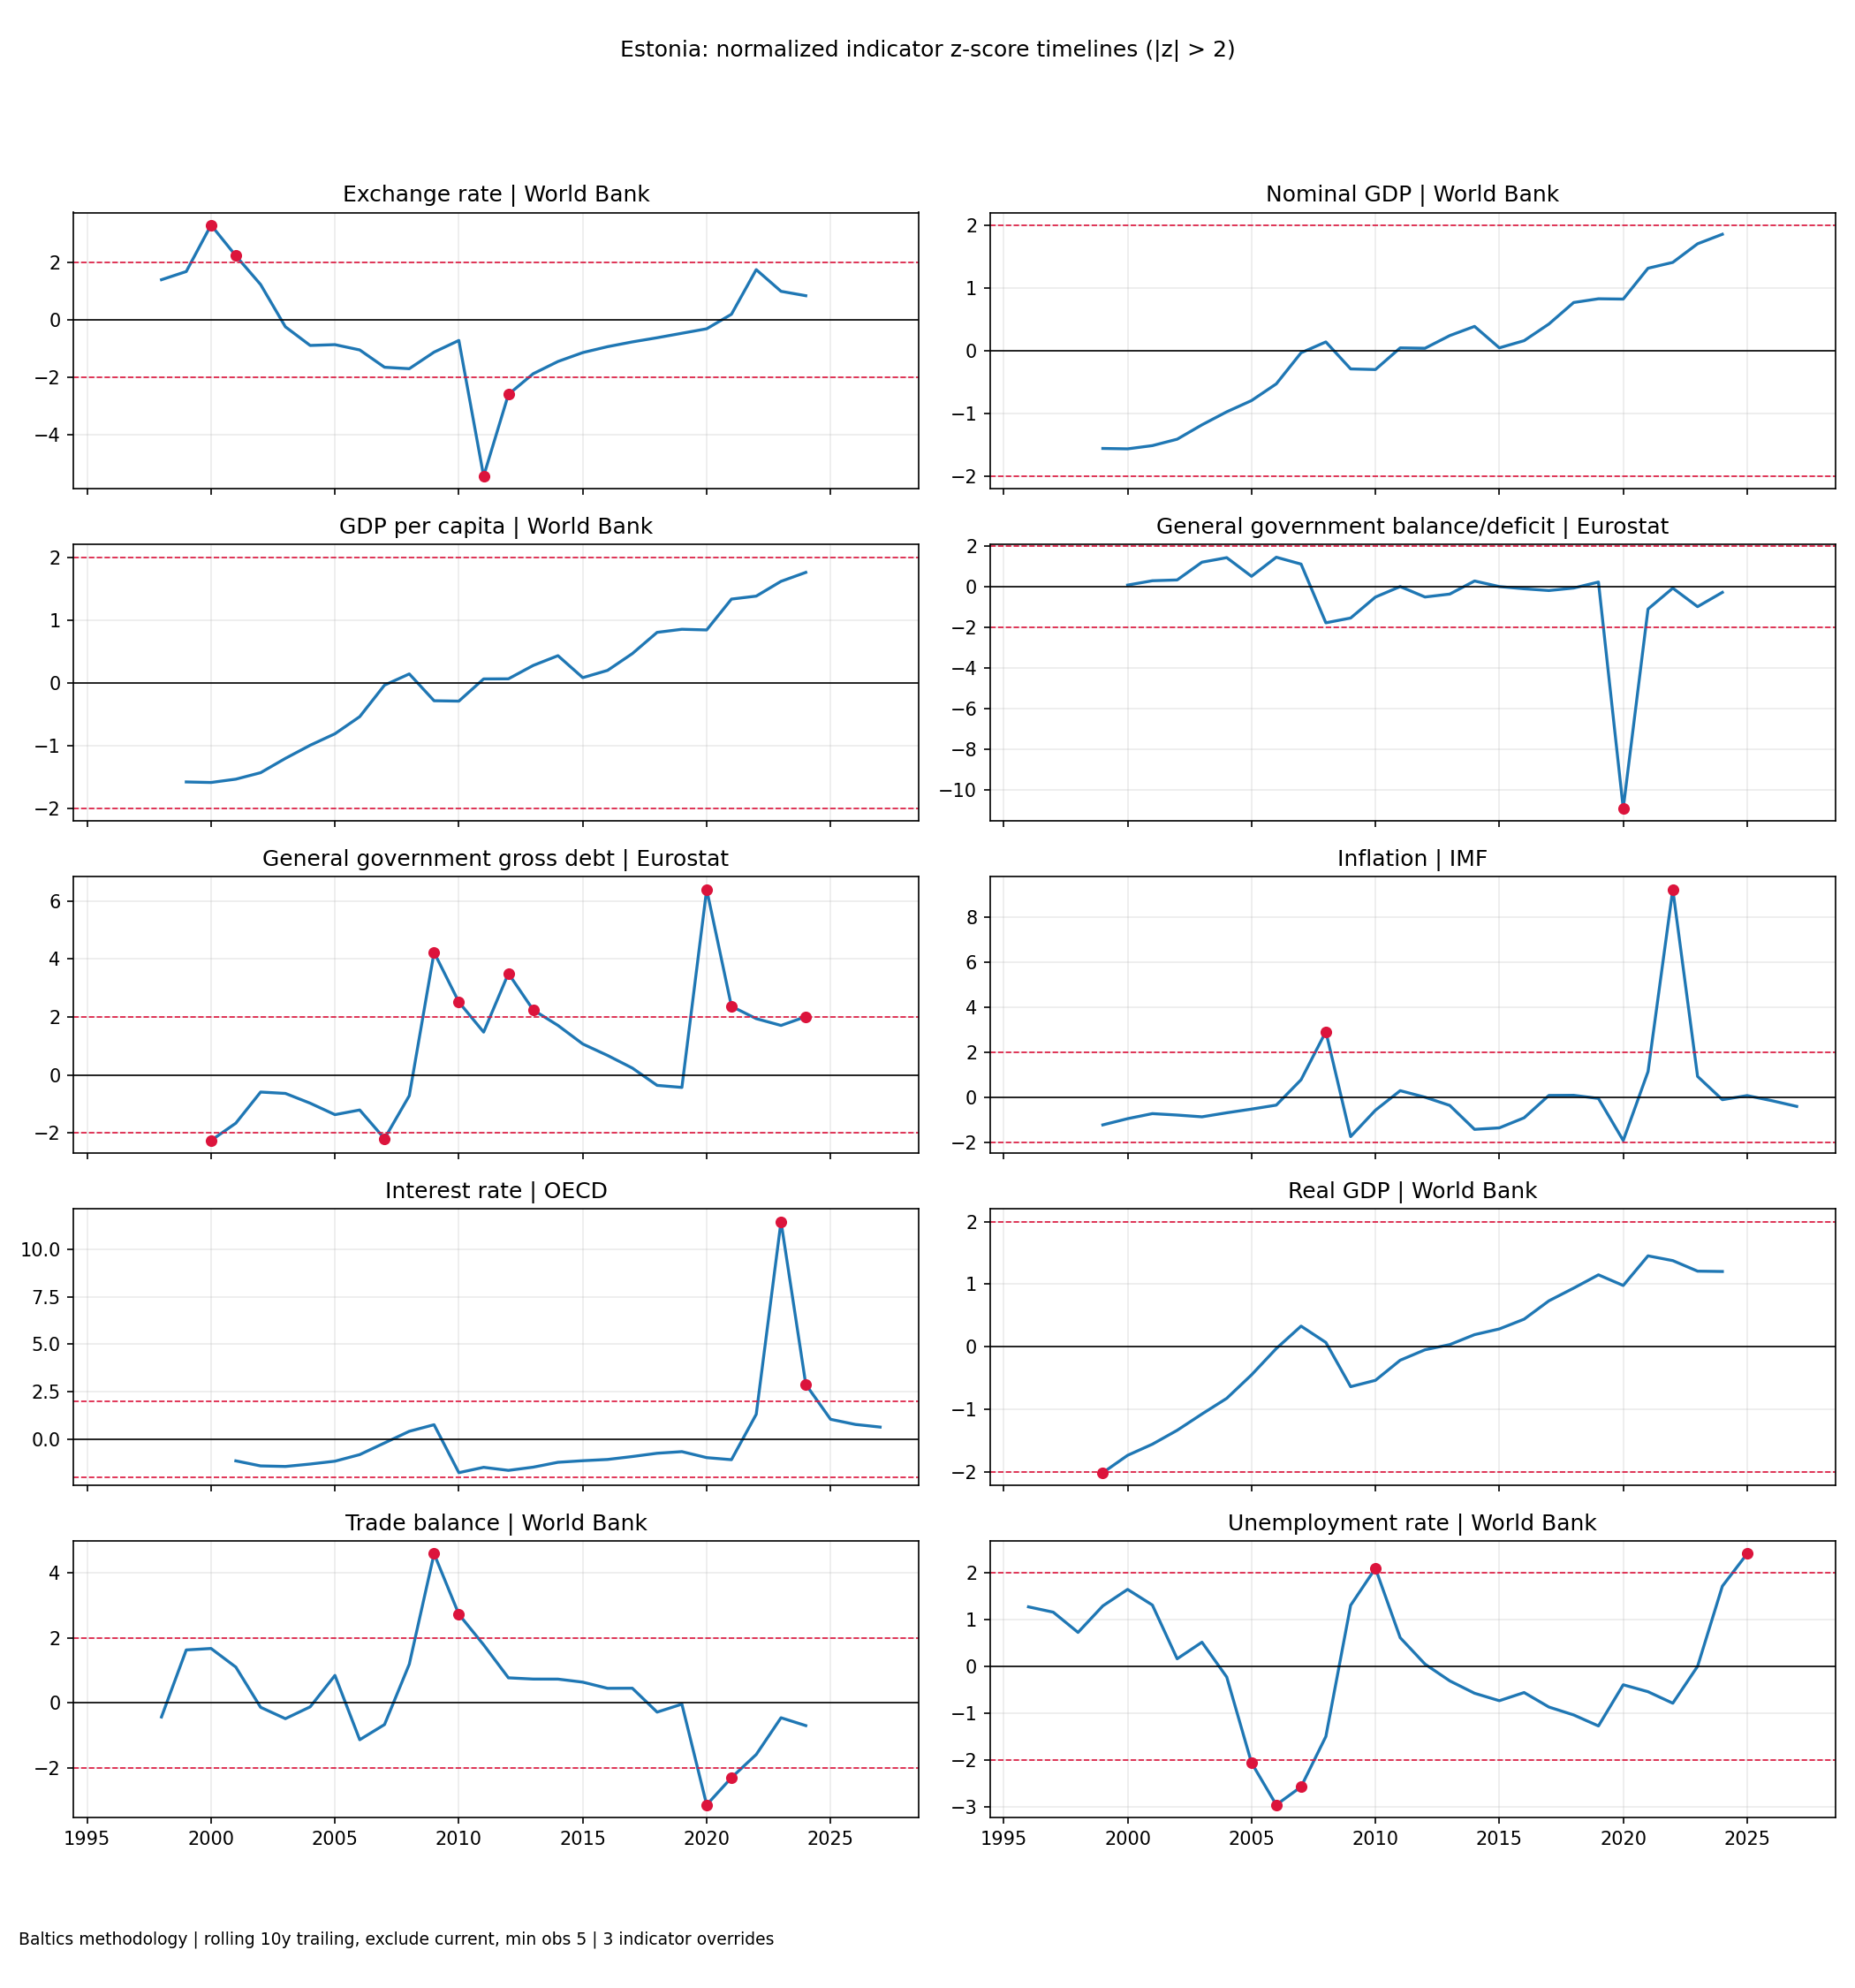

In [17]:
_ee_methodology_context = _render_country_methodology_section("EE", view_config=methodology_view_config)


This notebook reuses the cached Baltic batch outputs for source data. The presentation section writes curated shareable artifacts into dedicated `<country>/presentation_view` folders, while the methodology section reuses the dynamic helper artifacts under `<country>/charts/dynamic_zscore`. If you need to explain why a value appears in the presentation charts, the methodology section is the diagnostic view to check first.
